# 55: Indian matchbox label style LoRA on SDXL

Part of [Indian-Matchbox-Art-Style-Text-to-Image-Generator](https://github.com/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator).
Weights: [`sdxl/`](https://huggingface.co/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator/tree/main/sdxl) on Hugging Face.
Data: [spearb0lt/Indian-Matchbox-Labels](https://huggingface.co/datasets/spearb0lt/Indian-Matchbox-Labels).

---

## What this notebook is

A text-to-image **style LoRA** on Stable Diffusion XL, trained on 197 vintage Indian matchbox
labels, so that the trigger word `phlmx` produces new labels in that style. The emphasis is a
**curation-first workflow**: every step that decides quality is made explicit and measured.

**The method.** SDXL is a latent-diffusion **U-Net** trained to predict the **noise** ε that was
added to an image (the DDPM objective). The LoRA (rank 16, alpha 16) is attached to the U-Net's
attention projections `to_q`, `to_k`, `to_v` and `to_out.0`, and trained with that same noise
objective and min-SNR-5 loss weighting. Everything else stays frozen. Images are generated with
SDXL's default `EulerDiscreteScheduler`.

Notebook 69 trains a LoRA on the same 197 labels with a different model family and objective
(SD3.5-medium, a transformer trained with **flow matching**). The repository README compares the two.

**Where it started.** A Reddit post showed a style LoRA, trigger `desi-max`, trained on
`Qwen/Qwen-Image-2512` from about 70 to 78 hand-picked vintage South Asian commercial prints.
Qwen-Image has 20 B parameters, about 40 GB of weights at 2 bytes per parameter, so it does not fit
a 16 to 24 GB GPU. This notebook runs the same kind of workflow on SDXL, which fits. It uses its
own data, not the post's, which was never published.

| § | what |
|---|---|
| 2 | the training set: licence record, exact and near-duplicate removal (SHA-256, dHash, DINO), consistency review, a held-out split |
| 4 | **aspect-ratio bucketing**: labels are not square |
| 5 | **captioning**: Florence-2 auto-captions, the hand-written `.txt` captions, the *content, not style* rule, trigger placement |
| 6 | **repeats, epochs, steps**: at least 30 views of every training image |
| 8 | **caption ablation**: four caption strategies in short, otherwise identical runs |
| 9 | **the main run** and **checkpoint selection** on held-out prompts: CLIP style score, prompt adherence, and a memorisation check (DINO similarity to the training images) |
| 10 | reload from disk, and a **LoRA strength sweep** |
| 11 | **export**: diffusers and kohya-style safetensors, verified by a round trip |
| 12 | the run card, `CARD.json` |
| 13 | **generation**: a batch of prompts, a strength comparison, sizes, single images |

### The published run (the outputs below)

| | |
|---|---|
| data | `matchbox_india`: 197 labels, no duplicates found, 189 train and 8 held out |
| hardware | Google Colab, NVIDIA L4, bf16 |
| resolution | 1024-class aspect-ratio buckets (most images trained at 832 x 1216 or 1216 x 832) |
| captions | `content` (Florence-2 captions with style words removed) won the §8 ablation |
| schedule | 3 repeats x 10 epochs = 5 670 optimizer steps, 30 views per image, lr 1e-4, 124 min, peak 12.6 GiB |
| selected checkpoint | epoch 10 |
| held-out scores | style 0.583 (base model) to 0.672 (LoRA at 1.0); prompt adherence 0.321 to 0.320; 0 copies of training images |
| recommended scale | 1.0 |

### The data

| `FT_DATA_NAME` | what | trigger |
|---|---|---|
| `matchbox_india` **(default)** | 197 vintage Indian matchbox labels, one label per image, each with a hand-checked `.txt` content caption, downloaded from [spearb0lt/Indian-Matchbox-Labels](https://huggingface.co/datasets/spearb0lt/Indian-Matchbox-Labels) | `phlmx` |
| `museum` | the original stand-in: CC0 Cooper Hewitt, Smithsonian Design Museum prints, streamed from the Hugging Face Hub | `dsmx` |

`FT_STYLE_DIR` points the notebook at any other folder of images (optionally with same-named `.txt`
captions). **If the chosen data cannot be found, the setup cell stops with the reason. It never
falls back to other data.**

Everything a run produces is written to one folder, `<output root>/<FT_RUN_NAME>/` (on Colab, on
Google Drive under `My Drive/finetune_runs/`): checkpoints, the exported LoRA, the card, every
contact sheet and plot (`sheets/`), and every image generated in §13 (`generations/`).

| | QUICK (`FT_QUICK=1`, e.g. a 4 GB laptop GPU) | full (Colab L4 or A100; a T4 works, slower) |
|---|---|---|
| diffusion model | `hf-internal-testing/tiny-stable-diffusion-xl-pipe` (random weights, same SDXL classes, about 12 MB) | `stabilityai/stable-diffusion-xl-base-1.0` + `madebyollin/sdxl-vae-fp16-fix` |
| images | 8 train + 2 held out | every image in the folder except 8 held out |
| purpose | **every code path executes**; the images are noise | the actual training |

> In QUICK mode the tiny pipeline has random weights, so every CLIP number it produces is
> meaningless by construction. QUICK checks that the code runs, not that the method works.


## 0. Environment

In [4]:
import os
# Run options. Set them here, before the setup cell below.
os.environ.setdefault("FT_RUN_NAME", "55_matchbox_india")     # name of the output folder
# os.environ["FT_QUICK"] = "1"                                # fast smoke run with tiny models
# os.environ["FT_STYLE_DIR"] = "/path/to/your/images"         # train on your own folder instead


### Setup: data, output folder, and (on Colab) libraries and Drive

The next cell decides three things before anything else is loaded:

1. **Data.** `FT_DATA_NAME` (default `matchbox_india`) picks the training set. A local copy in
   `data/matchbox_india` is used if it exists; otherwise the cell downloads the Hugging Face
   dataset `spearb0lt/Indian-Matchbox-Labels` (about 130 MB) into that folder. `FT_STYLE_DIR`
   overrides both with any folder of images, and `FT_DATA_NAME = "museum"` uses the museum data.
   If the data cannot be found, the cell **stops** with the reason.
2. **Trigger.** `phlmx` for `matchbox_india`, `dsmx` otherwise, unless you set `FT_TRIGGER`.
3. **Output folder.** `<root>/<FT_RUN_NAME>`. On Colab the cell mounts Google Drive and the root
   is `My Drive/finetune_runs`, so nothing is lost when the runtime ends; elsewhere the root is
   `out`. `FT_OUT_ROOT` sets the root yourself.

On Colab it also installs the libraries. Do not import `huggingface_hub`, `transformers` or
`diffusers` in a cell before this one: if this cell upgrades a package that is already imported,
it stops and asks for one session restart.

**Resuming.** Every expensive step (captions, latents, baseline, the caption ablation, each
training epoch, the strength sweep) caches its result under `<output folder>/state` and reuses it
on a rerun, so a runtime that dies anywhere restarts where it stopped rather than at the top. Each
cache records a fingerprint of its inputs and recomputes itself if they change. To force work to
be redone: `FT_FRESH=1` for everything, or delete the one file in `state/` you want redone.


In [ ]:
import os as _os, sys as _sys, subprocess as _sp
from pathlib import Path as _P
try:
    import google.colab  # noqa: F401  (present on every Colab runtime)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

HF_DATASET = _os.environ.get("FT_HF_DATASET", "spearb0lt/Indian-Matchbox-Labels")     # the training images
DATA_NAME = _os.environ.get("FT_DATA_NAME") or ("custom" if _os.environ.get("FT_STYLE_DIR") else "matchbox_india")
_os.environ.setdefault("FT_TRIGGER", {"matchbox_india": "phlmx"}.get(DATA_NAME, "dsmx"))

if IN_COLAB:
    from importlib.metadata import version as _ver, PackageNotFoundError as _PNF
    _PKGS = ["huggingface_hub", "transformers", "diffusers", "peft", "accelerate", "safetensors", "datasets"]

    def _versions():
        out = {}
        for _p in _PKGS:
            try:
                out[_p] = _ver(_p)
            except _PNF:
                out[_p] = None
        return out

    _loaded = [p for p in _PKGS if p in _sys.modules]          # already imported in this session
    _before = _versions()
    _sp.run([_sys.executable, "-m", "pip", "install", "-q", "-U", "diffusers>=0.40", "transformers>=5.15", "peft>=0.20",
             "accelerate", "safetensors", "datasets", "huggingface_hub"], check=True)
    # Colab ships an old torchao; recent peft refuses to run next to torchao < 0.16. Nothing here uses it.
    try:
        if tuple(int(x) for x in _ver("torchao").split(".")[:2]) < (0, 16):
            _sp.run([_sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"], check=True)
    except Exception:
        pass                                   # not installed: nothing to do
    _changed = [p for p in _loaded if _versions()[p] != _before[p]]
    if _changed:                   # the old versions are still in memory; mixing them with the new files breaks imports
        raise RuntimeError(f"upgraded {_changed} after they were imported in this session. The new versions are "
                           "installed: do Runtime -> Restart session, then Run all again (this cell then passes).")
    # Outputs go to Google Drive, so checkpoints, weights and images survive the runtime.
    if not _os.environ.get("FT_OUT_ROOT"):
        from google.colab import drive as _drive
        _drive.mount("/content/drive")
        _os.environ["FT_OUT_ROOT"] = "/content/drive/MyDrive/finetune_runs"

# ---- the training images: never a silent fallback ----
_EXTS = (".jpg", ".jpeg", ".png", ".webp")
_has_imgs = lambda d: d.is_dir() and any(q.suffix.lower() in _EXTS for q in d.rglob("*"))
if not _os.environ.get("FT_STYLE_DIR") and DATA_NAME == "matchbox_india":
    _local = _P.cwd() / "data" / DATA_NAME
    if not _has_imgs(_local):                                   # not here yet: download it once
        from huggingface_hub import snapshot_download
        snapshot_download(HF_DATASET, repo_type="dataset", local_dir=str(_local))
    _dir = _local / "images" if _has_imgs(_local / "images") else _local
    if not _has_imgs(_dir):
        raise RuntimeError(f"no images found in {_local} (dataset {HF_DATASET}), so the run is stopped; it will NOT "
                           "fall back to other data. Set FT_STYLE_DIR to a folder of images instead.")
    _os.environ["FT_STYLE_DIR"] = str(_dir)
elif not _os.environ.get("FT_STYLE_DIR") and DATA_NAME != "museum":
    raise RuntimeError(f"unknown FT_DATA_NAME={DATA_NAME!r}: use 'matchbox_india', 'museum', or set FT_STYLE_DIR")

print(f"{'Colab' if IN_COLAB else 'local'} | data {DATA_NAME} | FT_STYLE_DIR = {_os.environ.get('FT_STYLE_DIR')} | "
      f"trigger {_os.environ['FT_TRIGGER']} | output root {_os.environ.get('FT_OUT_ROOT', 'out')}")


In [7]:
import sys

# Windows consoles default to cp1252 and cannot print some characters used below.
# Jupyter is unaffected; this matters when the notebook runs as a script.
if sys.platform == "win32":
    for _s in (sys.stdout, sys.stderr):
        try:
            _s.reconfigure(encoding="utf-8")
        except Exception:
            pass

In [8]:
import os, io, re, gc, json, math, time, copy, random, hashlib, shutil, warnings, subprocess
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

DEV = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = torch.cuda.is_bf16_supported(including_emulation=False) if DEV == "cuda" else False
DTYPE = torch.bfloat16 if BF16 else torch.float16      # T4/P100 -> fp16 (+ GradScaler, fp16-fix VAE)
if DEV == "cpu":
    DTYPE = torch.float32
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 2**30 if DEV == "cuda" else 0.0
torch.set_float32_matmul_precision("high")

QUICK = os.environ.get("FT_QUICK", "0") == "1"
if QUICK:
    print("=" * 78)
    print("QUICK MODE (FT_QUICK=1): tiny random-weight SDXL pipe, ~8 images, a few steps.")
    print("Every code path runs. Every image is noise. Draw NO conclusion from any number.")
    print("=" * 78)

print(f"device {DEV} | bf16 {BF16} -> {DTYPE}")
if DEV == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"gpu {torch.cuda.get_device_name(0)}  VRAM {free/2**30:.2f} GiB free / {total/2**30:.2f} GiB")
print("dtype is DERIVED: fp16 on T4/P100 (no bf16), with a GradScaler and fp32 LoRA params.")


def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


SEED = 42
set_seed(SEED)

device cuda | bf16 True -> torch.bfloat16
gpu NVIDIA L4  VRAM 21.84 GiB free / 22.03 GiB
dtype is DERIVED: fp16 on T4/P100 (no bf16), with a GradScaler and fp32 LoRA params.


In [9]:
MODEL_ID = "hf-internal-testing/tiny-stable-diffusion-xl-pipe" if QUICK else "stabilityai/stable-diffusion-xl-base-1.0"
VAE_ID = None if QUICK else "madebyollin/sdxl-vae-fp16-fix"     # the stock SDXL VAE overflows in fp16
CAPTIONER_ID = "florence-community/Florence-2-base"              # MIT, native transformers class, 463 MB
CLIP_ID = "openai/clip-vit-base-patch32"
DINO_ID = "facebook/dino-vits16"                                 # duplicate + memorisation detector (§2.3)
STYLE_DS = "biglam/cooper-hewitt-alt-text"                       # the museum data (FT_DATA_NAME="museum")
# The image folder was chosen by the setup cell (FT_DATA_NAME / FT_STYLE_DIR).
# FT_STYLE_LICENCE is an optional label recorded in the card; with your own folder nothing is gated on it.
STYLE_DIR = os.environ.get("FT_STYLE_DIR") or None
STYLE_LICENCE = os.environ.get("FT_STYLE_LICENCE", "").strip().lower() or "unspecified"
DATA_SOURCE = f"local folder {STYLE_DIR}" if STYLE_DIR else STYLE_DS
CREDIT = "" if STYLE_DIR else "Cooper Hewitt, Smithsonian Design Museum"

TRIGGER = os.environ.get("FT_TRIGGER", "phlmx")  # set by the setup cell from the dataset; §5.3 checks how it tokenizes
N_TRAIN = 8 if QUICK else 70                     # museum data; with your own folder §2.2b uses every image
N_HOLDOUT = 2 if QUICK else 8
N_SHARDS = 1 if QUICK else 21    # parquet shards to scan for metadata (the whole set has 21)
MAX_ROW_GROUPS = 1 if QUICK else 16
YEARS = (1940, 1985)
RANK = LORA_ALPHA = 16           # alpha == r: scale 1.0, the convention the kohya export assumes (§11)
LR = 1e-4
BATCH = 2 if QUICK else 1        # QUICK uses 2 so the multi-image bucket path runs
GRAD_ACC = 1
TARGET_STEPS = 16 if QUICK else 1400
TARGET_VIEWS = 1 if QUICK else 30  # at least this many views of every training image in the main run (§6)
EPOCHS = 4 if QUICK else 10
EVAL_EVERY = 1 if STYLE_DIR else 2 # epochs between evaluated checkpoints (every epoch is SAVED)
ABL_STEPS = 4 if QUICK else 350  # per caption variant in §8
GEN_STEPS = 4 if QUICK else 25
GUIDANCE = 6.0
GEN_BS = 2
RUN_NAME = os.environ.get("FT_RUN_NAME") or ("55_new_quick" if QUICK else "55_new")
OUT = Path(os.environ.get("FT_OUT_ROOT", "out")) / RUN_NAME      # everything this run writes lives here
SHEET_DIR, GEN_DIR = OUT / "sheets", OUT / "generations"
for _d in (OUT / "ckpt", OUT / "export", SHEET_DIR, GEN_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print(f"data: {DATA_SOURCE} | trigger {TRIGGER!r} | everything is saved under {OUT.resolve()}")

# Resumable stages. Every expensive step below writes its result under OUT/state and reuses it on a
# rerun, so a session killed anywhere restarts where it stopped instead of at the top. Each cache
# records a fingerprint of its inputs and recomputes itself when they change. FT_FRESH=1 ignores
# every cache; deleting one file in OUT/state redoes just that step.
STATE = OUT / "state"
STATE.mkdir(parents=True, exist_ok=True)
FRESH = os.environ.get("FT_FRESH", "0") == "1"


def fp(*parts):
    return hashlib.sha256(json.dumps(parts, sort_keys=True, default=str).encode()).hexdigest()[:16]


def stage(name, fn, key=""):
    p = STATE / f"{name}.pt"
    if p.exists() and not FRESH:
        blob = torch.load(p, map_location="cpu", weights_only=False)
        if blob.get("key") == key:
            print(f"[stage] {name}: reused from state/{p.name}")
            return blob["value"]
        print(f"[stage] {name}: inputs changed since it was cached -> recomputing")
    t0 = time.perf_counter()
    value = fn()
    torch.save({"key": key, "value": value}, p)
    print(f"[stage] {name}: computed in {time.perf_counter() - t0:.0f}s -> state/{p.name}")
    return value


def train_fp(*extra):
    """Fingerprint of the training set plus whatever else a stage depends on."""
    return fp([r["sha"] for r in TRAIN], MODEL_ID, QUICK, SEED, *extra)


print(f"resumable stages -> {STATE}   (FT_FRESH=1 recomputes everything)")

data: local folder /content/desi_repo/finetune/notebooks/data/matchbox_india | trigger 'phlmx' | everything is saved under /content/drive/MyDrive/finetune_runs/55_run2
resumable stages -> /content/drive/MyDrive/finetune_runs/55_run2/state   (FT_FRESH=1 recomputes everything)


## 1. The budget, before anything is downloaded

Weights only, at 2 bytes per parameter:

In [10]:
for name, params in [("Qwen-Image (the post)", 20e9), ("SDXL U-Net (this notebook)", 2.6e9)]:
    print(f"{name:<28} {params/1e9:>5.1f} B params x 2 bytes = {params*2/1e9:>5.1f} GB of weights")
print(f"\nthis GPU: {TOTAL_VRAM_GB:.1f} GiB.  A 16 GB T4 cannot even hold Qwen-Image's weights in bf16.")
print("""
The post's ~3 h on a 48 GB RTX 6000 Ada is not a number we can compare against: different model,
different card, unknown step count. What transfers is everything that happens BEFORE and AFTER
the optimizer loop, and that is what this notebook is about.""")

Qwen-Image (the post)         20.0 B params x 2 bytes =  40.0 GB of weights
SDXL U-Net (this notebook)     2.6 B params x 2 bytes =   5.2 GB of weights

this GPU: 22.0 GiB.  A 16 GB T4 cannot even hold Qwen-Image's weights in bf16.

The post's ~3 h on a 48 GB RTX 6000 Ada is not a number we can compare against: different model,
different card, unknown step count. What transfers is everything that happens BEFORE and AFTER
the optimizer loop, and that is what this notebook is about.


## 2. Building a small style set responsibly

With your own folder (the default `matchbox_india` is one) the images were curated before
training: §2.1 only records the licence, the museum cells of §2.2 are skipped, and the folder is
loaded by the cell after them (§2.2b). §2.3 onward runs for every data source.

### 2.1 The licence check comes first

A trained LoRA inherits the constraints of its base model **and** of its data, and the most
expensive time to discover a problem is after training. Three rules:

1. **Know where every image came from.** "It's on the internet" is not a licence, and age alone
   does not make a print public domain: copyright terms differ by country and by whether the
   author is known.
2. **Prefer per-item records over dataset-level tags.** A `license:` tag on a dataset card is a
   claim by the uploader. The Cooper Hewitt card also documents provenance: rows were kept only
   where the Smithsonian record's media object is marked CC0.
3. **Record it.** The licence goes into `CARD.json` (§12) and into the exported file's metadata (§11).

The `matchbox_india` set is of mixed provenance, recorded per image in its `sources.csv`: 131 images
from Wikimedia Commons, 46 from the Internet Archive and 20 collected from other websites whose
rights are unknown. It is published for research and education, and its licence is recorded here
as `unspecified`.


In [11]:
from huggingface_hub import HfApi, HfFileSystem

if STYLE_DIR:
    lic = [STYLE_LICENCE]
else:
    info = HfApi().dataset_info(STYLE_DS)
    cd = info.card_data.to_dict() if info.card_data else {}
    lic = cd.get("license")
    lic = [lic] if isinstance(lic, str) else list(lic or [])
LICENCE_RULES = {
    "cc0-1.0": "public-domain dedication: no conditions",
    "pddl": "public-domain dedication: no conditions",
    "cc-by-4.0": "OK: attribution must travel with the LoRA",
    "cc-by-sa-4.0": "CAUTION: share-alike may attach to derivatives",
}
print(f"{DATA_SOURCE}: declared licence {lic}")
for l in lic:
    print(f"   {l:<14} -> {LICENCE_RULES.get(l, 'NOT on the allow-list: stop and read the terms')}")
if STYLE_DIR:                     # your own folder: the licence is recorded, not enforced
    print("   own folder: licence recorded as-is in CARD.json and the export metadata; not gated")
else:
    assert lic and all(l in LICENCE_RULES for l in lic), "licence not cleared: do not train on this"
    assert not any("nc" in l for l in lic), "non-commercial data makes the LoRA non-commercial"
DATA_LICENCE = ",".join(lic)
if CREDIT:
    print(f"\nThe card also asks that you credit '{CREDIT}'. We will.")

local folder /content/desi_repo/finetune/notebooks/data/matchbox_india: declared licence ['unspecified']
   unspecified    -> NOT on the allow-list: stop and read the terms
   own folder: licence recorded as-is in CARD.json and the export metadata; not gated


### 2.2 Select by metadata first, then fetch only the images you need

The dataset is about 10 GB of parquet. We do **not** download it. Parquet is columnar, so
`pyarrow` can read the small metadata columns alone, over HTTP, from the Hub. Then it fetches
the `image` column only for the row groups that contain our candidates. (On a typical connection
the metadata of one shard takes tens of seconds, and one row group of images is about 100 MB
held in memory, never written to disk.)

The filter mirrors the post: **printed commercial matter** (posters, labels, packaging,
ephemera, prints) dated **1940-1985**, with the cataloguer's quality flags clean. South Asian
provenance is used for *ranking*, not filtering, because a museum collection in New York will
not contain 70 of them. The notebook prints how many it found.

In [12]:
if not STYLE_DIR:                 # museum path; your own folder is loaded in the next cell
    import pyarrow.parquet as pq

    fs = HfFileSystem()
    files = sorted(fs.glob(f"datasets/{STYLE_DS}/data/*.parquet"))[:N_SHARDS]
    META_COLS = ["title", "description", "object_type", "date", "medium", "maker",
                 "n_words", "has_crossref", "has_artifact", "record_id"]
    PF, parts, t0 = {}, [], time.perf_counter()
    for f in files:
        PF[f] = pq.ParquetFile(fs.open(f, "rb", block_size=2**18))
        for rg in range(PF[f].metadata.num_row_groups):
            t = PF[f].read_row_group(rg, columns=META_COLS).to_pandas()
            # no leading underscores: itertuples() would rename such columns to _1, _2 ...
            t["pfile"], t["prg"], t["pidx"] = f, rg, np.arange(len(t))
            parts.append(t)
    cat = pd.concat(parts, ignore_index=True)
    print(f"scanned {len(files)} shard(s), {len(cat):,} records, metadata only, in {time.perf_counter()-t0:.0f}s")
    print("most common object types:", Counter(cat["object_type"].fillna("").str.strip()).most_common(12))

In [13]:
if not STYLE_DIR:                 # museum path; your own folder is loaded in the next cell
    TYPE_KEYS = ["poster", "label", "advert", "ephemera", "trade card", "playing card", "greeting card",
                 "packag", "wrapper", "match", "calendar", "print", "book cover", "magazine", "brochure",
                 "postcard"]
    REGION_KEYS = ["india", "indian", "bombay", "calcutta", "madras", "delhi", "pakistan", "ceylon",
                   "bengal", "bangladesh", "nepal", "sri lanka", "karachi", "lahore"]


    def year_of(s):
        m = re.search(r"(1[5-9]\d\d|20[0-2]\d)", str(s or ""))
        return int(m.group(1)) if m else None


    text = (cat["title"].fillna("") + " " + cat["description"].fillna("") + " " +
            cat["maker"].fillna("")).str.lower()
    cat["year"] = pd.to_numeric(cat["date"].map(year_of), errors="coerce")
    cat["is_type"] = cat["object_type"].fillna("").str.lower().map(lambda s: any(k in s for k in TYPE_KEYS))
    cat["region"] = text.map(lambda s: any(k in s for k in REGION_KEYS))
    cat["clean"] = ~cat["has_crossref"].fillna(False).astype(bool) & ~cat["has_artifact"].fillna(False).astype(bool)

    N_POOL = int((N_TRAIN + N_HOLDOUT) * 1.6)          # headroom for dedup and hand-picking
    stages = [("type & 1940-1985", cat.is_type & cat.clean & cat.year.between(*YEARS)),
              ("type & 1920-1995", cat.is_type & cat.clean & cat.year.between(1920, 1995)),
              ("type only", cat.is_type & cat.clean),
              ("anything clean", cat.clean)]
    for name, mask in stages:
        print(f"   {name:<20} {int(mask.sum()):>6} candidates   ({int((mask & cat.region).sum())} South Asian)")
    STAGE, mask = next(((n, m) for n, m in stages if m.sum() >= N_POOL), stages[-1])
    cand = cat[mask].copy()
    print(f"\nusing stage '{STAGE}': {len(cand)} candidates")
    print("""(Relaxing a filter is a decision you should SEE. If the strict stage is too small for your
    target, the set becomes less consistent, and §2.4's review is where you find out whether it matters.)""")

    # choose the row groups that give the most candidates per 100 MB fetched
    rg_rank = (cand.groupby(["pfile", "prg"]).agg(n=("region", "size"), n_region=("region", "sum"))
               .sort_values(["n_region", "n"], ascending=False).reset_index())
    chosen, total = [], 0
    for f, rg, n, _ in rg_rank.itertuples(index=False, name=None):
        if total >= N_POOL or len(chosen) >= MAX_ROW_GROUPS:
            break
        chosen.append((f, int(rg))); total += int(n)
    print(f"fetching images from {len(chosen)} row group(s), ~{total} candidates")

In [14]:
if not STYLE_DIR:                 # museum path; your own folder is loaded in the next cell
    records, fetched_mb, t0 = [], 0.0, time.perf_counter()
    for f, rg in chosen:
        rgm = PF[f].metadata.row_group(rg)
        fetched_mb += sum(rgm.column(j).total_compressed_size for j in range(rgm.num_columns)
                          if rgm.column(j).path_in_schema.startswith("image")) / 1e6
        imgs = PF[f].read_row_group(rg, columns=["image"]).column("image").to_pylist()
        for row in cand[(cand.pfile == f) & (cand.prg == rg)].sort_values("region", ascending=False).itertuples():
            b = imgs[row.pidx]["bytes"]
            if not b:
                continue
            im = Image.open(io.BytesIO(b)).convert("RGB")
            records.append(dict(img=im, sha=hashlib.sha256(b).hexdigest(), title=row.title,
                                description=row.description, object_type=row.object_type, year=row.year,
                                region=bool(row.region), record_id=row.record_id, size=im.size))
        del imgs
    print(f"fetched {len(records)} images ({fetched_mb:.0f} MB over the network, in memory) "
          f"in {time.perf_counter()-t0:.0f}s")
    print(f"South Asian provenance among them: {sum(r['region'] for r in records)}")

In [15]:
# §2.2b Your own folder (FT_STYLE_DIR): load every image and fill the same record fields the museum path
# fills, so §2.3 onward (dedup, hand-pick review, split, captioning, training) runs unchanged.
if STYLE_DIR:
    STAGE, files, chosen, fetched_mb = "own folder", [], [], 0.0
    EXTS = {".jpg", ".jpeg", ".png", ".webp"}
    paths = sorted(q for q in Path(STYLE_DIR).rglob("*") if q.suffix.lower() in EXTS)
    assert paths, f"no .jpg/.jpeg/.png/.webp images found under {STYLE_DIR}"
    records = []
    for q in paths:
        b = q.read_bytes()
        im = Image.open(io.BytesIO(b)).convert("RGB")
        txt = q.with_suffix(".txt")      # optional hand-written caption, same name as the image
        records.append(dict(img=im, sha=hashlib.sha256(b).hexdigest(), title=q.stem,
                            description=txt.read_text(encoding="utf-8").strip() if txt.exists() else "",
                            object_type="", year=None, region=False,
                            record_id=q.relative_to(STYLE_DIR).as_posix(), size=im.size))
    print(f"loaded {len(records)} of your own images from {STYLE_DIR}; "
          f"{sum(bool(r['description']) for r in records)} have a .txt caption")
    if not QUICK:                    # a hand-curated folder: train on all of it, not the most typical subset
        N_TRAIN = len(records) - N_HOLDOUT
        print(f"every image is used: {N_TRAIN} train + {N_HOLDOUT} held out (before duplicate removal); "
              "use EXCLUDE in §2.4 to drop any by hand")

loaded 197 of your own images from /content/desi_repo/finetune/notebooks/data/matchbox_india; 197 have a .txt caption
every image is used: 189 train + 8 held out (before duplicate removal); use EXCLUDE in §2.4 to drop any by hand


### 2.3 Exact and near-duplicate removal

Duplicates are effectively a per-example learning-rate multiplier. With 30 views per image, one image present three times is trained on
90 times, and it is the one the LoRA will reproduce. Collections are full of near-duplicates: the
same label scanned twice, a reprint in another colourway, two photographs of one object.

Three detectors:

* **SHA-256** of the file: byte-identical copies.
* **dHash** (a 64-bit perceptual hash): re-scans and re-encodings; misses crops.
* **DINO image cosine** (`facebook/dino-vits16`, self-supervised): crops, re-scans, colour shifts.

**Why DINO and not CLIP.** CLIP embeds what an image *is about* and its style, so two different
labels in one shared style land close together. Measured on the 197 matchbox labels: a degraded
copy of a label scores CLIP ≥ 0.817 with its original (5th percentile), but the nearest *different*
label scores a median 0.786, and 63 of 197 distinct labels exceed 0.817, so a CLIP threshold would
have merged 53 genuinely different labels into "duplicate" groups. DINO keeps instances apart:
copies score ≥ 0.924 (1st percentile), the most similar two different labels 0.868.

**The threshold is calibrated, not guessed.** We make a synthetic copy of every image
(downscale, JPEG q=60, a 4 % crop) and measure how similar DINO thinks each copy is to its
original. The 5th percentile of those copy-similarities becomes `COPY_T`, the level at which we
call two images "the same picture". The same threshold drives the memorisation check in §9.

In [16]:
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor

clip =CLIPModel.from_pretrained(CLIP_ID, dtype=torch.float16 if DEV == "cuda" else torch.float32).to(DEV).eval()
cproc = CLIPProcessor.from_pretrained(CLIP_ID)


def _feat(out):
    # transformers 5.x returns BaseModelOutputWithPooling here (projection in .pooler_output),
    # not a tensor as in 4.x. Handle both so a version bump cannot silently break the metric.
    return out.pooler_output if hasattr(out, "pooler_output") else out


@torch.no_grad()
def clip_img(imgs, bs=16):
    out = []
    for s in range(0, len(imgs), bs):
        px = cproc(images=[i.convert("RGB") for i in imgs[s:s + bs]], return_tensors="pt")["pixel_values"]
        out.append(F.normalize(_feat(clip.get_image_features(pixel_values=px.to(DEV, clip.dtype))).float(), dim=-1).cpu())
    return torch.cat(out)


@torch.no_grad()
def clip_txt(texts):
    t = cproc(text=texts, return_tensors="pt", padding=True, truncation=True)
    out = clip.get_text_features(input_ids=t["input_ids"].to(DEV), attention_mask=t["attention_mask"].to(DEV))
    return F.normalize(_feat(out).float(), dim=-1).cpu()


def dhash(im, n=8):
    a = np.asarray(im.convert("L").resize((n + 1, n), Image.LANCZOS), dtype=np.int16)
    return (a[:, 1:] > a[:, :-1]).flatten()


from transformers import AutoImageProcessor, ViTModel

dino = ViTModel.from_pretrained(DINO_ID, add_pooling_layer=False).to(DEV).eval()
dproc = AutoImageProcessor.from_pretrained(DINO_ID)


@torch.no_grad()
def dino_img(imgs, bs=16):
    """L2-normalised DINO [CLS] embeddings: an instance-level 'is this the same picture' signal."""
    out = []
    for s in range(0, len(imgs), bs):
        px = dproc(images=[i.convert("RGB") for i in imgs[s:s + bs]], return_tensors="pt")["pixel_values"].to(DEV)
        out.append(F.normalize(dino(pixel_values=px).last_hidden_state[:, 0].float(), dim=-1).cpu())
    return torch.cat(out)


def show_fig(name):
    """Save the current matplotlib figure to SHEET_DIR, then display it."""
    plt.savefig(SHEET_DIR / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


def fake_copy(im):
    w, h = im.size
    small = im.resize((max(8, w // 2), max(8, h // 2)), Image.BICUBIC)
    buf = io.BytesIO(); small.save(buf, "JPEG", quality=60)
    c = Image.open(buf).convert("RGB")
    cw, ch = c.size
    return c.crop((int(.04 * cw), int(.04 * ch), int(.96 * cw), int(.96 * ch)))


# exact duplicates
seen, uniq = set(), []
for r in records:
    if r["sha"] not in seen:
        seen.add(r["sha"]); uniq.append(r)
print(f"exact duplicates removed: {len(records) - len(uniq)}")

D_pool = dino_img([r["img"] for r in uniq])
copy_sims = (D_pool * dino_img([fake_copy(r["img"]) for r in uniq])).sum(-1).numpy()
COPY_T = float(np.percentile(copy_sims, 5))
S = (D_pool @ D_pool.T).numpy(); np.fill_diagonal(S, -1)
H = np.stack([dhash(r["img"]) for r in uniq])
print(f"DINO similarity of an image to its degraded copy: p5 {COPY_T:.3f}  median {np.median(copy_sims):.3f}")
print(f"DINO nearest-neighbour similarity between DIFFERENT pool images: median {np.median(S.max(1)):.3f}  "
      f"max {S.max():.3f}  (well below COPY_T = the detector separates copies from look-alikes)")

parent = list(range(len(uniq)))


def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]; i = parent[i]
    return i


pairs = []
for i in range(len(uniq)):
    for j in range(i + 1, len(uniq)):
        ham = int((H[i] != H[j]).sum())
        if ham <= 6 or S[i, j] >= COPY_T:
            parent[find(i)] = find(j); pairs.append((i, j, ham, float(S[i, j])))
groups = defaultdict(list)
for i in range(len(uniq)):
    groups[find(i)].append(i)
keep = [max(g, key=lambda k: uniq[k]["size"][0] * uniq[k]["size"][1]) for g in groups.values()]
dups = [g for g in groups.values() if len(g) > 1]
print(f"near-duplicate groups: {len(dups)}  -> kept {len(keep)} of {len(uniq)}")
if dups:
    g = dups[0]
    fig, ax = plt.subplots(1, min(4, len(g)), figsize=(3.2 * min(4, len(g)), 3.4))
    for a, k in zip(np.atleast_1d(ax), g[:4]):
        a.imshow(uniq[k]["img"]); a.axis("off"); a.set_title(str(uniq[k]["title"])[:28], fontsize=7)
    plt.suptitle("one near-duplicate group: only the largest is kept"); plt.tight_layout(); show_fig("2.3_near_duplicate_group")
pool = [uniq[k] for k in sorted(keep)]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

exact duplicates removed: 0


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.7MB            

model.safetensors: downloading bytes:           |  0.00B            

DINO similarity of an image to its degraded copy: p5 0.934  median 0.963
DINO nearest-neighbour similarity between DIFFERENT pool images: median 0.736  max 0.868  (well below COPY_T = the detector separates copies from look-alikes)
near-duplicate groups: 0  -> kept 197 of 197


### 2.4 Consistency review: the "hand-picked" step

The post's set was *hand-picked*, and that is the step no filter replaces. A style LoRA learns
the **average** of its images. Two unrelated looks average into mud. The code can only *rank* candidates for your review, least
typical first, using CLIP similarity to the pool centroid. The decision is yours: put indices
into `EXCLUDE` and rerun from here.

After review, the pool is split into **train** and a small **held-out style set**. The style
score in §9 compares generations with *held-out* images. Comparing with the training images
would reward copying, which is the thing we are trying to detect. Dedup ran over the whole pool
*before* this split, so no near-twin can straddle it.

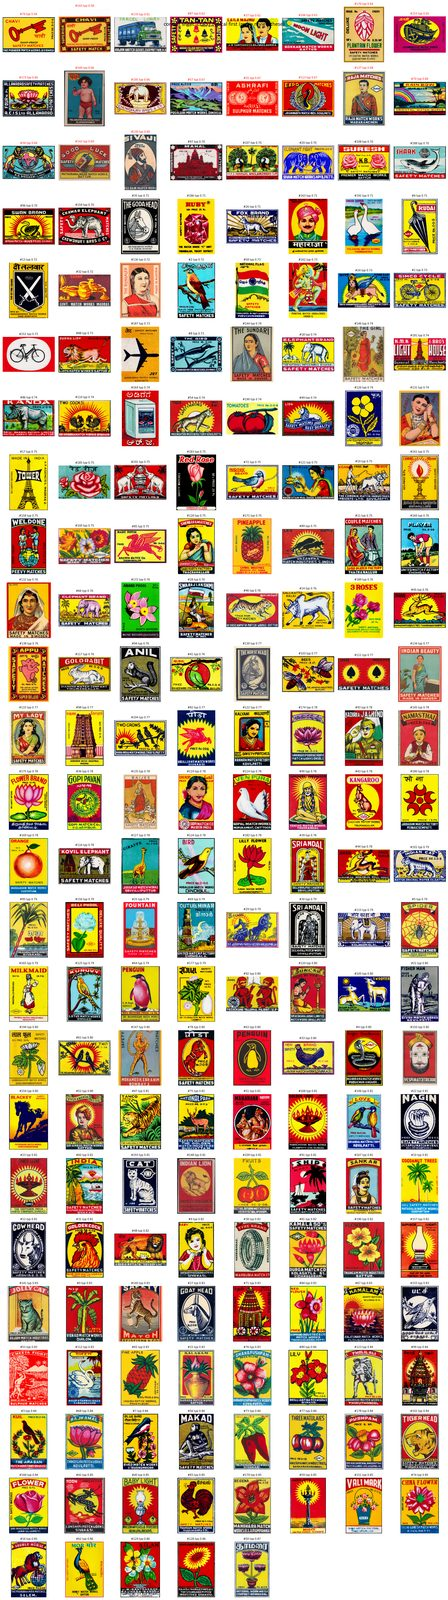

kept 197; dropped as least typical / excluded: []
train 189  held-out style 8
mean pairwise CLIP cosine within train: 0.591  (a diversity check; compare it across candidate sets, not against a fixed bar)


In [17]:
EXCLUDE = []                    # <- your hand-picking goes here (indices into the sheet below)
E_p = clip_img([r["img"] for r in pool])
typ = (E_p @ F.normalize(E_p.mean(0), dim=0)).numpy()
order = np.argsort(typ)
ncol = 8
nrow = math.ceil(len(pool) / ncol)
fig, ax = plt.subplots(nrow, ncol, figsize=(2.1 * ncol, 2.4 * nrow))
for a in np.atleast_1d(ax).ravel():
    a.axis("off")
for a, k in zip(np.atleast_1d(ax).ravel(), order):
    a.imshow(pool[k]["img"]); a.set_title(f"#{k} typ {typ[k]:.2f}", fontsize=7,
                                          color="red" if k in order[:max(1, len(pool) // 10)] else "black")
plt.suptitle("contact sheet, LEAST typical first (red = review these)"); plt.tight_layout(); show_fig("2.4_contact_sheet_least_typical_first")

sel = [k for k in np.argsort(-typ) if k not in set(EXCLUDE)][: N_TRAIN + N_HOLDOUT]
dropped = [k for k in range(len(pool)) if k not in sel]
print(f"kept {len(sel)}; dropped as least typical / excluded: {dropped}")
assert len(sel) >= 3, "too few images survived: widen the selection in §2.2"
rng = np.random.default_rng(SEED)
perm = rng.permutation(sel)
n_hold = N_HOLDOUT if len(perm) >= N_HOLDOUT + 3 else 1
HOLD = [pool[k] for k in perm[:n_hold]]
TRAIN = [pool[k] for k in perm[n_hold:]]
E_train = clip_img([r["img"] for r in TRAIN])
E_hold = clip_img([r["img"] for r in HOLD])
D_train = dino_img([r["img"] for r in TRAIN])          # for the memorisation check (§7, §9)
STYLE_CENTROID = F.normalize(E_hold.mean(0), dim=0)
pw = (E_train @ E_train.T).numpy()
print(f"train {len(TRAIN)}  held-out style {len(HOLD)}" +
      ("" if STYLE_DIR else f"  South Asian in train: {sum(r['region'] for r in TRAIN)}"))
print(f"mean pairwise CLIP cosine within train: {(pw.sum()-len(pw))/(len(pw)**2-len(pw)):.3f}  "
      "(a diversity check; compare it across candidate sets, not against a fixed bar)")

## 3. The pipeline

Loaded once. The two text encoders are used to embed every caption and prompt (§7) and then
**freed**. From there on, generation runs from pre-computed embeddings. SDXL's `__call__` in
diffusers 0.40.0 explicitly supports `text_encoder_2=None` when `pooled_prompt_embeds` are
passed, and it reads the projection width from the pooled tensor instead.

In [18]:
from diffusers import StableDiffusionXLPipeline, AutoencoderKL, DDPMScheduler

kw = dict(dtype=DTYPE)
if VAE_ID:
    kw["vae"] = AutoencoderKL.from_pretrained(VAE_ID, dtype=DTYPE)
if not QUICK:
    kw.update(variant="fp16", use_safetensors=True)
pipe = StableDiffusionXLPipeline.from_pretrained(MODEL_ID, **kw)
pipe.set_progress_bar_config(disable=True)
unet, vae = pipe.unet, pipe.vae
VAE_SCALE = 2 ** (len(vae.config.block_out_channels) - 1)
UNET_DOWN = 2 ** (len(unet.config.down_block_types) - 1)
print(f"U-Net {sum(p.numel() for p in unet.parameters())/1e6:.1f} M params   "
      f"VAE downsample x{VAE_SCALE}   U-Net downsample x{UNET_DOWN}   "
      f"scaling_factor {vae.config.scaling_factor}   prediction_type {pipe.scheduler.config.prediction_type}")
POOLED_DIM = pipe.text_encoder_2.config.projection_dim
assert unet.config.addition_time_embed_dim * 6 + POOLED_DIM == unet.config.projection_class_embeddings_input_dim, \
    "time_ids layout does not match this U-Net"
print("micro-conditioning layout verified: 6 time ids x "
      f"{unet.config.addition_time_embed_dim} + pooled {POOLED_DIM} = {unet.config.projection_class_embeddings_input_dim}")

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

U-Net 2567.5 M params   VAE downsample x8   U-Net downsample x4   scaling_factor 0.13025   prediction_type epsilon
micro-conditioning layout verified: 6 time ids x 256 + pooled 1280 = 2816


## 4. Aspect-ratio bucketing

Posters and labels are tall; packaging is often wide. A square centre crop throws away the
masthead or the footer, which is exactly where the typography that defines the style sits.
**Bucketing** trains each image at the bucket shape closest to its aspect ratio, with roughly
constant pixel area, so that the memory per step stays roughly constant. Every image in a batch
must share a bucket, because latents of different shapes cannot be stacked.

Bucket sides must be multiples of the VAE × U-Net downsampling (so the latents divide evenly
through the U-Net). We use 64 px for SDXL, the kohya convention, which is coarser than the
minimum of 32.

We also choose the **training resolution from the data**: the highest of 768, 896 and 1024 at
which at most a quarter of the images would need upscaling, because upscaled images teach
upscaling artefacts. No matchbox image needs upscaling even at 1024, so this run trains at 1024.

In [19]:
STEP = max(VAE_SCALE * UNET_DOWN, 8 if QUICK else 64)


def make_buckets(base, step=STEP, lo=0.5, hi=2.0):
    out, area = set(), base * base
    for w in range(step, 2 * base + 1, step):
        h = int(area / w) // step * step
        if h >= step and lo <= w / h <= hi:
            out.add((w, h))
    return sorted(out)


def assign(size, buckets):
    W, H = size
    return min(buckets, key=lambda b: abs(math.log(b[0] / b[1]) - math.log(W / H)))


def upscale_needed(size, b):
    return max(b[0] / size[0], b[1] / size[1])


print(f"{'base':>6}{'buckets':>9}{'imgs upscaled >1.15x':>22}")
res_table = {}
for base in [768, 896, 1024]:
    bk = make_buckets(base, step=64)
    up = np.array([upscale_needed(r["size"], assign(r["size"], bk)) for r in TRAIN])
    res_table[base] = float((up > 1.15).mean())
    print(f"{base:>6}{len(bk):>9}{100*res_table[base]:>21.0f}%")
RES_AUTO = max([b for b in res_table if res_table[b] <= 0.25] or [768])
RESOLUTION = 64 if QUICK else RES_AUTO
ABL_RES = 64 if QUICK else 512
print(f"-> training resolution {RESOLUTION} (data-driven choice {RES_AUTO}); ablation at {ABL_RES}")

BUCKETS = make_buckets(RESOLUTION)
bk_of = [assign(r["size"], BUCKETS) for r in TRAIN]
sq_kept = np.mean([min(r["size"]) ** 2 / (r["size"][0] * r["size"][1]) for r in TRAIN])
bk_kept = np.mean([(b[0] * b[1]) / (math.ceil(r["size"][0] * upscale_needed(r["size"], b)) *
                                     math.ceil(r["size"][1] * upscale_needed(r["size"], b)))
                   for r, b in zip(TRAIN, bk_of)])
print(f"\nimage area KEPT: square centre crop {100*sq_kept:.1f}%   bucketing {100*bk_kept:.1f}%")
print("bucket occupancy:", dict(Counter(bk_of).most_common()))
print("""
Note what bucketing does NOT include: horizontal flips. Every print here carries lettering, and a
flip mirrors it.""")

  base  buckets  imgs upscaled >1.15x
   768        8                    0%
   896       10                    0%
  1024       11                    0%
-> training resolution 1024 (data-driven choice 1024); ablation at 512

image area KEPT: square centre crop 67.5%   bucketing 96.9%
bucket occupancy: {(832, 1216): 104, (1216, 832): 47, (1280, 768): 15, (896, 1152): 14, (768, 1344): 9}

Note what bucketing does NOT include: horizontal flips. Every print here carries lettering, and a
flip mirrors it.


## 5. Captioning

### 5.1 Auto-captions with Florence-2-base

`florence-community/Florence-2-base` is MIT-licensed. It loads through the native
`Florence2ForConditionalGeneration` class in transformers 5.15.1, so no `trust_remote_code`,
and it fits a 3050. Its `<DETAILED_CAPTION>` task produces a sentence or two of content.

In [20]:
TASK = "<DETAILED_CAPTION>"


def _caption_train():
    from transformers import AutoProcessor, Florence2ForConditionalGeneration

    cap_proc = AutoProcessor.from_pretrained(CAPTIONER_ID)
    cap_model = Florence2ForConditionalGeneration.from_pretrained(CAPTIONER_ID, dtype=DTYPE).to(DEV).eval()

    @torch.no_grad()
    def caption(imgs, bs=4):
        out = []
        for s in range(0, len(imgs), bs):
            chunk = imgs[s:s + bs]
            inp = cap_proc(text=[TASK] * len(chunk), images=chunk, return_tensors="pt").to(DEV, DTYPE)
            ids = cap_model.generate(**inp, max_new_tokens=40 if QUICK else 96, num_beams=3, do_sample=False)
            for im, txt in zip(chunk, cap_proc.batch_decode(ids, skip_special_tokens=False)):
                out.append(cap_proc.post_process_generation(txt, task=TASK, image_size=im.size)[TASK])
        return out

    caps = caption([r["img"] for r in TRAIN])
    gc.collect()                      # cap_model/cap_proc are locals: returning drops them
    if DEV == "cuda":
        torch.cuda.empty_cache()
    return caps


# The captioner is only downloaded and run when this stage is not already cached.
RAW_CAPS = stage("raw_caps", _caption_train, key=train_fp(CAPTIONER_ID, TASK))
assert len(RAW_CAPS) == len(TRAIN), "cached captions do not match the training set"
print(f"{len(RAW_CAPS)} captions for {len(TRAIN)} training images")


processor_config.json:   0%|          | 0.00/2.26k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/198k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  463MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/665 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

[stage] raw_caps: computed in 60s -> state/raw_caps.pt
189 captions for 189 training images


### 5.2 The rule for style LoRAs: describe the content, not the style

*Whatever you do not caption is what
the trigger absorbs.* A captioner looking at a 1950s poster will say "a vintage poster
illustration of…". If "vintage poster illustration" stays in every caption, those words, not
your trigger, absorb the look. Then at inference the trigger does little and the ordinary words
carry the style everywhere.

So we strip style, medium and genre words and the captioner's boilerplate. We keep **objects,
people, layout and the text printed on the item**. Captioning the lettering matters: recurring
words that go uncaptioned get baked into the trigger, and every generation starts sprouting the
same brand name.

**Known issue in the published run.** The printed examples below show that some cleaned captions
still end in `<pad>` tokens: Florence-2 is decoded with `skip_special_tokens=False`, which its
post-processor needs, and nothing here strips the padding afterwards. §5.3 also shows that 77 % of
the captions are longer than SDXL's 77-token text limit, so their ends, where Florence-2 usually
quotes the label's printed text, are cut off during training. Both weaken what the LoRA learns
about lettering. For a re-run: remove `"<pad>"` in `strip_style`, and ask Florence-2 for shorter
captions (a lower `max_new_tokens`).

In [21]:
STYLE_WORDS = ["vintage", "retro", "antique", "old-fashioned", "poster", "print", "printed", "lithograph",
               "lithographic", "illustration", "illustrated", "drawing", "painting", "artwork", "graphic",
               "advertisement", "advertising", "halftone", "screenprint", "woodcut", "engraving", "etching",
               "sketch", "cartoon", "colorful", "colourful", "style", "design", "label"]
_GENRE = r"(poster|print|illustration|drawing|painting|advertisement|label|artwork|image|picture|design)"
PHRASE = re.compile(rf"\b(an?|the)\s+(\w+\s+){{0,3}}{_GENRE}\s+(of|for|showing|with|depicting|featuring)\s+", re.I)
BOILER = re.compile(r"^(the image (is|shows|depicts)|this (image )?is|in this image,?( we can see)?)\s*", re.I)
WORDS = re.compile(r"\b(" + "|".join(map(re.escape, STYLE_WORDS)) + r")s?\b", re.I)


def strip_style(c):
    c = BOILER.sub("", c.strip())
    c = PHRASE.sub("", c)
    c = WORDS.sub("", c)
    c = re.sub(r"\s+([,.;:])", r"\1", re.sub(r"\s{2,}", " ", c))
    c = re.sub(r"^(an?|the)\s+(of|for|with)\s+", "", c.strip(" ,.;:"), flags=re.I)
    return c.strip(" ,.;:") or "an object"


CONTENT = [strip_style(c) for c in RAW_CAPS]
had_style = np.mean([bool(WORDS.search(c) or PHRASE.search(c)) for c in RAW_CAPS])
print(f"raw captions containing at least one style/genre word: {100*had_style:.0f}%\n")
for raw_c, c, r in list(zip(RAW_CAPS, CONTENT, TRAIN))[:5]:
    print(f"RAW     : {raw_c[:150]}")
    print(f"CONTENT : {c[:150]}")
    print(f"{'HUMAN   ' if STYLE_DIR else 'MUSEUM  '}: {str(r['description'])[:150]}\n")
print("The human-written description (your .txt, or the museum cataloguer's) is a third caption source: "
      "with your own folder it enters the §8 ablation as 'human'.")

raw captions containing at least one style/genre word: 92%

RAW     : The image shows a poster of a woman in a red sari standing in front of a group of people, with curtains in the background. The text on the poster read
CONTENT : a woman in a red sari standing in front of a group of people, with curtains in the background. The text on the reads "Baijee Safety Matches Made in In
HUMAN   : a matchbox label, a woman dancing on a stage with red curtains while seated men watch, headline 'Baijee', the Wimco logo, text 'Safety matches made in

RAW     : The image shows a poster with a painting of a bird perched atop a flower, surrounded by leaves and flowers. The poster also has text written on it, li
CONTENT : a bird perched atop a flower, surrounded by leaves and flowers. The also has text written on it, likely describing the bird and its surroundings.<pad>
HUMAN   : a matchbox label, a dark bird perched inside a wreath of red flowers, yellow background, headline 'KUIL', text 'The Arasan M

### 5.3 Trigger token and placement: measured, not assumed

SDXL's tokenizers truncate at 77 tokens. A trigger appended at the **end** of a long caption is
cut off in exactly the captions that most need it. A trigger that splits into common sub-words
(`desi` `-` `max`?) shares its embedding with words the model already knows, which is usually
not what you want. Both are cheap to check with the pipeline's own tokenizer.
(In QUICK the tiny pipe's 1 000-token vocabulary makes these counts meaningless.)

In [22]:
tok = pipe.tokenizer
for cand_tr in ["desi-max", TRIGGER, "ohwx", "sks"]:
    pieces = tok.convert_ids_to_tokens(tok(cand_tr, add_special_tokens=False).input_ids)
    print(f"   {cand_tr!r:<12} -> {pieces}")

L = tok.model_max_length
lens = np.array([len(tok(f"{TRIGGER}, {c}").input_ids) for c in CONTENT])
n_trig = len(tok(TRIGGER, add_special_tokens=False).input_ids)
# the suffix trigger sits just before EOS, so it is cut whenever the whole caption exceeds L
suffix_lost = np.mean([len(tok(f"{c}, {TRIGGER}").input_ids) > L for c in CONTENT])
print(f"\ntrigger '{TRIGGER}' = {n_trig} token(s)")
print(f"caption length in tokens: p50 {np.percentile(lens,50):.0f}  p90 {np.percentile(lens,90):.0f}  "
      f"max {lens.max()}  (limit {L})")
print(f"trigger as SUFFIX would be truncated in {100*suffix_lost:.0f}% of captions; as PREFIX in 0%.")
print(f"-> the trigger goes FIRST: '{TRIGGER}, <content>'.")

CAPTIONS = {
    "content": [f"{TRIGGER}, {c}" for c in CONTENT],          # the §52.3 rule
    "trigger_only": [TRIGGER] * len(CONTENT),                  # trigger absorbs content too
    "raw": [f"{TRIGGER}, {c}" for c in RAW_CAPS],              # style words compete with the trigger
}
if STYLE_DIR and all(r["description"] for r in TRAIN):
    # your .txt captions, style-stripped by the same rule; the §8 ablation decides whether they win
    CAPTIONS["human"] = [f"{TRIGGER}, {strip_style(r['description'])}" for r in TRAIN]
    print("human (.txt) caption example:", CAPTIONS["human"][0][:150])

   'desi-max'   -> ['desi</w>', '-</w>', 'max</w>']
   'phlmx'      -> ['ph', 'lm', 'x</w>']
   'ohwx'       -> ['ohwx</w>']
   'sks'        -> ['sks</w>']

trigger 'phlmx' = 3 token(s)
caption length in tokens: p50 90  p90 127  max 152  (limit 77)
trigger as SUFFIX would be truncated in 77% of captions; as PREFIX in 0%.
-> the trigger goes FIRST: 'phlmx, <content>'.
human (.txt) caption example: phlmx, a matchbox, a woman dancing on a stage with red curtains while seated men watch, headline 'Baijee', the Wimco logo, text 'Safety matches made i


## 6. Repeats, epochs, steps: how many times each image is seen

In kohya-style trainers, **repeats** multiply how many times each image appears *per epoch*.
With a single image folder, repeats × epochs is all that matters to the optimiser. Repeats only
decide how long an "epoch" is, and so how far apart your per-epoch checkpoints land.

$$\text{optimizer steps} = \frac{N \times \text{repeats} \times \text{epochs}}{B \times \text{accum}},\qquad
  \text{views per image} = \text{repeats} \times \text{epochs}$$

Two targets pin the choice: about 1 000 to 3 000 steps is a common range for a style LoRA, and
8 to 15 saved checkpoints give the best one a chance to exist. The number worth watching is
*views per image*: every example is seen, individually, again and again. With 189 training images
the 30-views target dominates, so this run takes 5 670 steps.

In [23]:
N = len(TRAIN)
print(f"N = {N}, batch {BATCH}, accum {GRAD_ACC}")
print(f"{'repeats':>8}{'epochs':>8}{'steps':>8}{'views/img':>11}{'ckpts':>7}")
for rep, ep in [(1, 10), (2, 10), (3, 10), (5, 6), (10, 3), (20, 2)]:
    st = N * rep * ep // (BATCH * GRAD_ACC)
    print(f"{rep:>8}{ep:>8}{st:>8}{rep*ep:>11}{ep:>7}")
# whichever is larger: the step budget, or TARGET_VIEWS views of every image (a big set needs more steps)
REPEATS = max(1, round(max(TARGET_STEPS * BATCH * GRAD_ACC / N, TARGET_VIEWS) / EPOCHS))
STEPS = N * REPEATS * EPOCHS // (BATCH * GRAD_ACC)
print(f"\nchosen: repeats {REPEATS} x epochs {EPOCHS} -> ~{STEPS} optimizer steps, "
      f"{REPEATS*EPOCHS} views per image, {EPOCHS} checkpoints saved, "
      f"{len(range(EVAL_EVERY, EPOCHS + 1, EVAL_EVERY))} evaluated")
print("""
(10 repeats x 3 epochs and 3 repeats x 10 epochs are the SAME training. The second gives you ten
checkpoints to choose from instead of three.)""")

N = 189, batch 1, accum 1
 repeats  epochs   steps  views/img  ckpts
       1      10    1890         10     10
       2      10    3780         20     10
       3      10    5670         30     10
       5       6    5670         30      6
      10       3    5670         30      3
      20       2    7560         40      2

chosen: repeats 3 x epochs 10 -> ~5670 optimizer steps, 30 views per image, 10 checkpoints saved, 10 evaluated

(10 repeats x 3 epochs and 3 repeats x 10 epochs are the SAME training. The second gives you ten
checkpoints to choose from instead of three.)


## 7. Encode once, cache everything, and take the baseline

Captions for all three variants, held-out prompts with and without the trigger, and two
**regurgitation probes** (training captions verbatim) are embedded with the pipeline's own
`encode_prompt`. That way training and inference cannot disagree about which CLIP layer or
pooling is used. Then the text encoders are dropped.

In [24]:
HELDOUT = ["a bicycle leaning against a brick wall", "a lighthouse on a rocky coast at dusk",
           "a family of elephants crossing a river", "a steaming cup of tea on a wooden table",
           "a woman riding a scooter through a busy street", "a rocket launching at night"]
if QUICK:
    HELDOUT = HELDOUT[:2]
N_PROBE = 1 if QUICK else 2


@torch.no_grad()
def encode(texts, bs=16):
    pe, pp = [], []
    for s in range(0, len(texts), bs):
        e, _, p, _ = pipe.encode_prompt(texts[s:s + bs], device=DEV, num_images_per_prompt=1,
                                        do_classifier_free_guidance=False)
        pe.append(e.cpu()); pp.append(p.cpu())
    return torch.cat(pe), torch.cat(pp)


pipe.text_encoder.to(DEV); pipe.text_encoder_2.to(DEV)
EMB = {v: encode(c) for v, c in CAPTIONS.items()}
EMB["held_trig"] = encode([f"{TRIGGER}, {h}" for h in HELDOUT])
EMB["held_plain"] = encode(HELDOUT)
EMB.update({f"probe_{v}": encode(c[:N_PROBE]) for v, c in CAPTIONS.items()})
print({k: tuple(v[0].shape) for k, v in EMB.items()})

gen_pipe = StableDiffusionXLPipeline(vae=vae, text_encoder=None, text_encoder_2=None,
                                     tokenizer=pipe.tokenizer, tokenizer_2=pipe.tokenizer_2,
                                     unet=unet, scheduler=pipe.scheduler, add_watermarker=False)
gen_pipe.set_progress_bar_config(disable=True)
del pipe; gc.collect()
if DEV == "cuda":
    torch.cuda.empty_cache()
unet.to(DEV); vae.to(DEV)
print("text encoders freed; generation now runs from cached embeddings.")

{'content': (189, 77, 2048), 'trigger_only': (189, 77, 2048), 'raw': (189, 77, 2048), 'human': (189, 77, 2048), 'held_trig': (6, 77, 2048), 'held_plain': (6, 77, 2048), 'probe_content': (2, 77, 2048), 'probe_trigger_only': (2, 77, 2048), 'probe_raw': (2, 77, 2048), 'probe_human': (2, 77, 2048)}
text encoders freed; generation now runs from cached embeddings.


In [25]:
from torchvision.transforms import functional as TF


@torch.no_grad()
def build_cache(res):
    bks = make_buckets(res)
    g = torch.Generator(DEV).manual_seed(SEED)
    cache = []
    for r in TRAIN:
        W, H = r["size"]
        bw, bh = assign((W, H), bks)
        s = upscale_needed((W, H), (bw, bh))
        nw, nh = math.ceil(W * s), math.ceil(H * s)
        im = r["img"].resize((nw, nh), Image.LANCZOS)
        left, top = (nw - bw) // 2, (nh - bh) // 2
        im = im.crop((left, top, left + bw, top + bh))
        px = (TF.to_tensor(im) * 2 - 1)[None].to(DEV, vae.dtype)
        lat = vae.encode(px).latent_dist.sample(generator=g) * vae.config.scaling_factor
        cache.append({"latent": lat[0].cpu(), "bucket": (bw, bh),
                      # SDXL micro-conditioning: TRUE original size, REAL crop offset
                      "time_ids": torch.tensor([H, W, top, left, bh, bw], dtype=torch.float32)})
    return cache


_RES_LIST = sorted({RESOLUTION, ABL_RES})
CACHES = stage("latents", lambda: {r: build_cache(r) for r in _RES_LIST},
               key=train_fp(_RES_LIST, VAE_ID, STEP))
print(f"latents at {list(CACHES)} px; "
      f"e.g. {tuple(CACHES[RESOLUTION][0]['latent'].shape)} for bucket {CACHES[RESOLUTION][0]['bucket']}")

[stage] latents: computed in 72s -> state/latents.pt
latents at [512, 1024] px; e.g. (4, 168, 96) for bucket (768, 1344)


[stage] baseline: computed in 87s -> state/baseline.pt
BASELINE (no adapter): {'style': 0.5834084153175354, 'adherence': 0.32090747356414795, 'nn_max': 0.39538857340812683, 'copies': 0, 'probe_nn_max': 0.500113308429718, 'probe_copies': 0}   10.9 s/image
calibration: base-model generations reach nn_max 0.395 against the training images; the copy threshold is 0.934. A LoRA that drives nn toward COPY_T is copying.


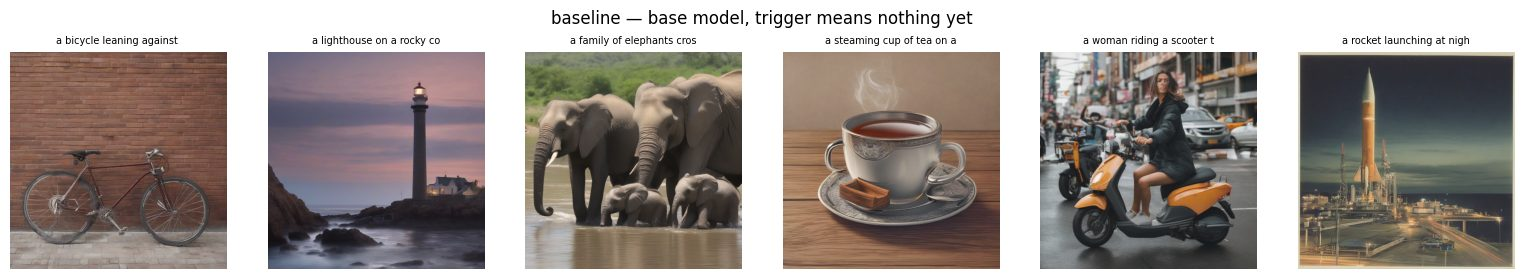

In [26]:
@torch.no_grad()
def generate(key, res, seed=SEED, scale=None):
    """Fixed seeds per prompt, so checkpoints / scales differ only by the adapter."""
    pe, pp = EMB[key]
    imgs, xa = [], ({} if scale is None else {"cross_attention_kwargs": {"scale": float(scale)}})
    unet.eval()
    for s in range(0, len(pe), GEN_BS):
        gens = [torch.Generator(DEV).manual_seed(seed + i) for i in range(s, min(s + GEN_BS, len(pe)))]
        with torch.autocast(DEV, dtype=DTYPE, enabled=(DEV == "cuda")):
            imgs += gen_pipe(prompt_embeds=pe[s:s + GEN_BS].to(DEV, DTYPE),
                             pooled_prompt_embeds=pp[s:s + GEN_BS].to(DEV, DTYPE),
                             height=res, width=res, num_inference_steps=GEN_STEPS,
                             guidance_scale=GUIDANCE, generator=gens, **xa).images
    return imgs


T_HELD = clip_txt(HELDOUT)


def score(imgs, probe_imgs=None):
    """style: cosine to HELD-OUT style centroid.  adherence: cosine to the content prompt.
    nn: max DINO cosine to any TRAINING image. >= COPY_T means 'DINO calls it the same picture'."""
    E_g = clip_img(imgs)
    nn = (dino_img(imgs) @ D_train.T).max(1).values
    out = {"style": float((E_g @ STYLE_CENTROID).mean()), "adherence": float((E_g * T_HELD).sum(-1).mean()),
           "nn_max": float(nn.max()), "copies": int((nn >= COPY_T).sum())}
    if probe_imgs is not None:
        nnp = (dino_img(probe_imgs) @ D_train.T).max(1).values
        out.update(probe_nn_max=float(nnp.max()), probe_copies=int((nnp >= COPY_T).sum()))
    return out


def sheet(rows, titles, suptitle):
    fig, ax = plt.subplots(len(rows), len(rows[0]), figsize=(2.6 * len(rows[0]), 2.8 * len(rows)), squeeze=False)
    for i, row in enumerate(rows):
        for j, im in enumerate(row):
            ax[i, j].imshow(im); ax[i, j].axis("off")
            ax[i, j].set_title(titles[i][j] if isinstance(titles[i], list) else (titles[i] if j == 0 else ""), fontsize=7)
    plt.suptitle(suptitle); plt.tight_layout()
    show_fig(re.sub(r"[^a-z0-9]+", "_", suptitle.lower()).strip("_")[:70])      # saved to SHEET_DIR too


def _baseline():
    t0 = time.perf_counter()
    imgs = generate("held_trig", RESOLUTION)
    sec = (time.perf_counter() - t0) / len(imgs)
    return {"imgs": imgs, "gen_sec": sec, "score": score(imgs, generate("probe_content", RESOLUTION))}


_b = stage("baseline", _baseline, key=train_fp(RESOLUTION, GEN_STEPS, GUIDANCE, len(HELDOUT)))
base_imgs, GEN_SEC, BASE = _b["imgs"], _b["gen_sec"], _b["score"]
print(f"BASELINE (no adapter): {BASE}   {GEN_SEC:.1f} s/image")
print(f"calibration: base-model generations reach nn_max {BASE['nn_max']:.3f} against the training "
      f"images; the copy threshold is {COPY_T:.3f}. A LoRA that drives nn toward COPY_T is copying.")
sheet([base_imgs], [[h[:26] for h in HELDOUT]], "baseline: base model, trigger means nothing yet")

## 8. The caption ablation

Short, otherwise identical runs, one per caption variant (four here, because the folder has `.txt` captions), that differ **only in the captions**. Each is scored on held-out
prompts twice, with the trigger and without it:

* **trigger gain** = style(with trigger) − style(without). A high gain means the style bound to
  the *trigger*. A low gain with high no-trigger style means it **bled** into ordinary words.
* **adherence** with the trigger: does the prompt still decide the subject?

The usual expectation is that `content` wins on gain without losing adherence, `trigger_only` loses
adherence, and `raw` loses gain. The ablation checks that prediction on *your* data, at low
resolution to keep it cheap. The main run uses the winner.

In [27]:
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict, set_peft_model_state_dict
from diffusers.training_utils import cast_training_params, compute_snr
from diffusers.optimization import get_scheduler
from safetensors.torch import load_file

noise_sched = DDPMScheduler.from_config(gen_pipe.scheduler.config)
PRED_TYPE = noise_sched.config.prediction_type
unet.requires_grad_(False)
vae.requires_grad_(False)
unet.enable_gradient_checkpointing()
LORA_TARGETS = ["to_k", "to_q", "to_v", "to_out.0"]


def bucket_batches(n_items, repeats, batch, rng_, cache):
    idx = [i for i in range(n_items) for _ in range(repeats)]
    byb = defaultdict(list)
    for i in idx:
        byb[cache[i]["bucket"]].append(i)
    out = []
    for lst in byb.values():
        rng_.shuffle(lst)
        out += [lst[s:s + batch] for s in range(0, len(lst), batch)]
    rng_.shuffle(out)
    return out


def add_lora(name):
    unet.add_adapter(LoraConfig(r=RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian",
                                target_modules=LORA_TARGETS), adapter_name=name)
    cast_training_params(unet, dtype=torch.float32)       # LoRA params fp32; base stays DTYPE
    params = [p for p in unet.parameters() if p.requires_grad]
    n_ad = sum(1 for n, _ in unet.named_modules() if n.endswith(f"lora_A.{name}"))
    bmax = max(p.detach().abs().max().item() for n, p in unet.named_parameters() if f"lora_B.{name}" in n)
    assert n_ad > 0, "no adapters attached"
    assert bmax == 0.0, "lora_B != 0 at init: the base model is perturbed before step 0"
    assert all(p.dtype == torch.float32 for p in params), "fp16 trainable params break the GradScaler"
    return params, n_ad


def save_ckpt(name, path):
    sd = {k: v.detach().to(torch.float16).cpu() for k, v in get_peft_model_state_dict(unet, adapter_name=name).items()}
    StableDiffusionXLPipeline.save_lora_weights(
        path, unet_lora_layers=sd, safe_serialization=True,
        unet_lora_adapter_metadata=unet.peft_config[name].to_dict())   # restores rank AND alpha on load
    return path


def latest_ckpt(ckpt_dir):
    if FRESH or os.environ.get("FT_RESUME", "1") == "0":
        return 0
    eps = [int(p.name[2:]) for p in Path(ckpt_dir).glob("ep*")
           if p.name[2:].isdigit() and any(p.glob("*.safetensors"))]
    return max(eps, default=0)


def load_ckpt(name, path):
    f = next(iter(Path(path).glob("*.safetensors")))
    sd = {k[5:]: v for k, v in load_file(f).items() if k.startswith("unet.")}   # save_lora_weights prefixes "unet."
    set_peft_model_state_dict(unet, sd, adapter_name=name)
    bmax = max(p.detach().abs().max().item() for n, p in unet.named_parameters() if f"lora_B.{name}" in n)
    assert bmax > 0, f"resume read {f} but lora_B is still zero: nothing was loaded"


def train_run(name, variant, res, epochs, repeats, on_epoch=None, log_every=50, resume_dir=None):
    cache = CACHES[res]
    params, n_ad = add_lora(name)
    opt = torch.optim.AdamW(params, lr=LR, betas=(0.9, 0.999), weight_decay=1e-2)
    per_epoch = math.ceil(len(bucket_batches(len(cache), repeats, BATCH, random.Random(0), cache)) / GRAD_ACC)
    total = per_epoch * epochs
    sched = get_scheduler("cosine", optimizer=opt, num_warmup_steps=max(1, total // 20), num_training_steps=total)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEV == "cuda" and DTYPE == torch.float16))
    emb, pooled = EMB[variant]
    rng_, step, hist, t0 = random.Random(SEED), 0, [], time.perf_counter()
    done = latest_ckpt(resume_dir) if resume_dir else 0     # epochs left on disk by an interrupted run
    if done >= epochs:
        # every checkpoint is on disk but the run never returned (it died in the final evaluation),
        # so redo the last epoch only: that rebuilds the summary without repeating the whole run
        done = epochs - 1
        print(f"  [{name}] all {epochs} checkpoints exist but the run never finished; redoing epoch {epochs}")
    if done:
        load_ckpt(name, Path(resume_dir) / f"ep{done:02d}")
        step = per_epoch * done
        for _ in range(step):
            sched.step()                                               # put the cosine LR back where it was
        for _ in range(done):
            bucket_batches(len(cache), repeats, BATCH, rng_, cache)     # and the shuffle, so the order continues
        print(f"  [{name}] resuming at epoch {done + 1}/{epochs} from ep{done:02d}. Weights come from the fp16 "
              f"checkpoint and the AdamW moments restart at zero, so this is not identical to an uninterrupted "
              f"run, and epochs <= {done} are not re-evaluated.")
    if DEV == "cuda":
        torch.cuda.reset_peak_memory_stats()
    first_grad_checked = False
    for ep in range(done + 1, epochs + 1):
        unet.train()
        batches = bucket_batches(len(cache), repeats, BATCH, rng_, cache)
        for bi, b in enumerate(batches):
            lat = torch.stack([cache[i]["latent"] for i in b]).to(DEV, torch.float32)
            e = emb[b].to(DEV, DTYPE); p = pooled[b].to(DEV, DTYPE)
            tids = torch.stack([cache[i]["time_ids"] for i in b]).to(DEV, DTYPE)
            noise = torch.randn_like(lat)
            t = torch.randint(0, noise_sched.config.num_train_timesteps, (len(b),), device=DEV).long()
            noisy = noise_sched.add_noise(lat, noise, t)
            with torch.autocast(DEV, dtype=DTYPE, enabled=(DEV == "cuda")):
                pred = unet(noisy.to(DTYPE), t, encoder_hidden_states=e,
                            added_cond_kwargs={"text_embeds": p, "time_ids": tids}).sample
            target = noise if PRED_TYPE == "epsilon" else noise_sched.get_velocity(lat, noise, t)
            snr = compute_snr(noise_sched, t)                                    # min-SNR-5
            w = torch.clamp(snr, max=5.0) / (snr if PRED_TYPE == "epsilon" else snr + 1)
            loss = (F.mse_loss(pred.float(), target.float(), reduction="none").mean([1, 2, 3]) * w).mean() / GRAD_ACC
            scaler.scale(loss).backward()
            if not first_grad_checked:
                g = [q.grad.norm().item() for q in params if q.grad is not None]
                assert g and max(g) > 0, "ZERO GRADIENTS into the LoRA"
                first_grad_checked = True
            if (bi + 1) % GRAD_ACC == 0 or bi == len(batches) - 1:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                scaler.step(opt); scaler.update(); sched.step()
                opt.zero_grad(set_to_none=True); step += 1
                if step % log_every == 0:
                    print(f"    [{name}] step {step}/{total}  loss {loss.item()*GRAD_ACC:.4f}  (noisy by design)")
        rec = {"epoch": ep, "step": step, "sec": time.perf_counter() - t0}
        if on_epoch is not None:
            rec.update(on_epoch(name, ep) or {})
        hist.append(rec)
    peak = torch.cuda.max_memory_allocated() / 2**30 if DEV == "cuda" else 0.0
    return hist, dict(adapters=n_ad, steps=step, seconds=time.perf_counter() - t0, peak_gib=peak,
                      trainable=sum(q.numel() for q in params), steps_run=step - per_epoch * done)

[stage] abl_content: computed in 468s -> state/abl_content.pt
content       gain +0.0028  style(trig) 0.5940  style(plain) 0.5912  adherence 0.3137  378 steps 429s
[stage] abl_trigger_only: computed in 472s -> state/abl_trigger_only.pt
trigger_only  gain +0.0012  style(trig) 0.6144  style(plain) 0.6132  adherence 0.2884  378 steps 434s
[stage] abl_raw: computed in 466s -> state/abl_raw.pt
raw           gain -0.0084  style(trig) 0.5961  style(plain) 0.6045  adherence 0.3006  378 steps 428s
[stage] abl_human: computed in 467s -> state/abl_human.pt
human         gain -0.0152  style(trig) 0.5780  style(plain) 0.5932  adherence 0.3076  378 steps 429s
[stage] base_abl: computed in 16s -> state/base_abl.pt

base adherence at 512px: 0.2803
chosen caption strategy: 'content'   (usual expectation: 'content'; agreement: True)


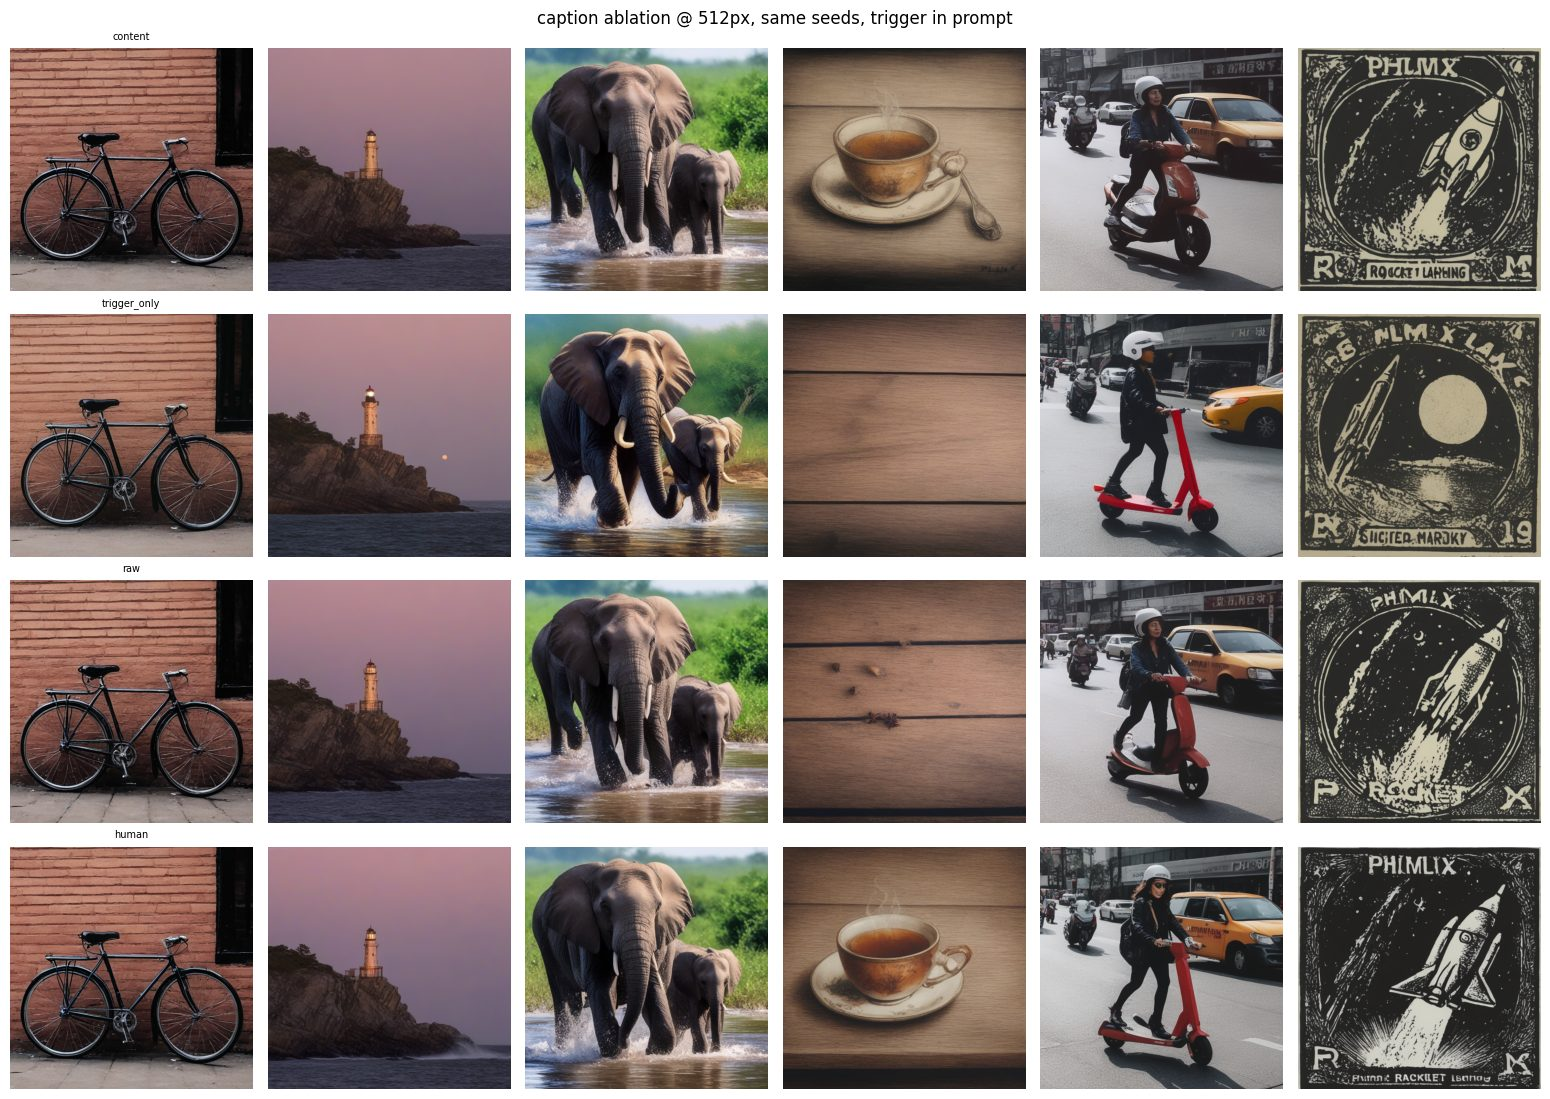

In [28]:
abl_epochs = max(1, round(ABL_STEPS * BATCH / (len(TRAIN))))


def _abl_variant(variant):
    set_seed(SEED)
    name = f"abl_{variant}"
    _, meta_ = train_run(name, variant, ABL_RES, epochs=abl_epochs, repeats=1, log_every=10**9)
    with_t, without_t = generate("held_trig", ABL_RES), generate("held_plain", ABL_RES)
    s_w, s_wo = score(with_t), score(without_t)
    unet.delete_adapters(name)
    return {"row": {"style_trig": s_w["style"], "style_plain": s_wo["style"],
                    "trigger_gain": s_w["style"] - s_wo["style"], "adherence": s_w["adherence"],
                    "copies": s_w["copies"], **meta_},
            "imgs": with_t}


# One cached stage per variant: a crash in the middle keeps the variants that already finished.
ABL, abl_imgs = {}, {}
_ABL_KEY = train_fp(sorted(CAPTIONS), ABL_RES, abl_epochs, RANK, LORA_ALPHA, LR, ABL_STEPS)
for variant in CAPTIONS:
    _r = stage(f"abl_{variant}", lambda v=variant: _abl_variant(v), key=_ABL_KEY)
    ABL[variant], abl_imgs[variant] = _r["row"], _r["imgs"]
    print(f"{variant:<13} gain {ABL[variant]['trigger_gain']:+.4f}  style(trig) {ABL[variant]['style_trig']:.4f}  "
          f"style(plain) {ABL[variant]['style_plain']:.4f}  adherence {ABL[variant]['adherence']:.4f}  "
          f"{ABL[variant]['steps']} steps {ABL[variant]['seconds']:.0f}s")

base_abl = stage("base_abl", lambda: score(generate("held_trig", ABL_RES)), key=_ABL_KEY)
ok = [v for v in ABL if ABL[v]["adherence"] >= base_abl["adherence"] - 0.02]
CHOSEN = max(ok or list(ABL), key=lambda v: ABL[v]["trigger_gain"])
print(f"\nbase adherence at {ABL_RES}px: {base_abl['adherence']:.4f}")
print(f"chosen caption strategy: '{CHOSEN}'   (usual expectation: 'content'; "
      f"agreement: {CHOSEN == 'content'})")
sheet([abl_imgs[v] for v in CAPTIONS], list(CAPTIONS), f"caption ablation @ {ABL_RES}px, same seeds, trigger in prompt")


## 9. The main run, and choosing the checkpoint by evaluation

Every epoch is **saved**. Every `EVAL_EVERY` epochs the in-memory adapter generates the
held-out grid plus the regurgitation probes with fixed seeds. The training loss is not
consulted: it tracks the sampled timestep, not quality.

**Selection rule** (evaluate every checkpoint on something real, pick afterwards):
1. discard checkpoints with **any held-out generation at or above `COPY_T`** to a training image;
2. discard checkpoints whose adherence fell more than 0.02 below the base model's;
3. of the rest, take the highest style score.

Probe copies (a training caption reproducing its training image) are reported separately. They
are the most sensitive memorisation signal and the first to rise.

**If the runtime dies mid-run,** every finished epoch is already on Drive, so re-running the cell
resumes from the highest `ckpt/epNN` it finds instead of starting over (`FT_RESUME=0` forces a
fresh run). Only the weights are restored, not the optimiser moments, so a resumed run is not
identical to an uninterrupted one; and the epochs trained before the interruption are not
re-evaluated, so the selection below ranks only the checkpoints this session scored.

In [29]:
TRAIN_STATE = STATE / "train.json"
EVALS, SHEETS, HIST, MAIN = {}, {}, None, None
if TRAIN_STATE.exists() and not FRESH:
    _s = json.load(open(TRAIN_STATE))
    EVALS = {int(k): v for k, v in _s.get("evals", {}).items()}
    HIST, MAIN = _s.get("hist"), _s.get("main")
    print(f"[stage] main: recovered evals for epochs {sorted(EVALS)}; "
          f"finished={MAIN is not None}")


def _save_train_state():
    json.dump({"evals": EVALS, "hist": HIST, "main": MAIN}, open(TRAIN_STATE, "w"), default=str)


def on_epoch(name, ep):
    path = save_ckpt(name, str(OUT / "ckpt" / f"ep{ep:02d}"))
    if ep % EVAL_EVERY and ep != EPOCHS:
        return {"ckpt": path}
    imgs = generate("held_trig", RESOLUTION)
    s = score(imgs, generate(f"probe_{CHOSEN}", RESOLUTION))
    EVALS[ep], SHEETS[ep] = s, imgs
    _save_train_state()           # the curve is on Drive before the next epoch can crash
    unet.train()
    print(f"  epoch {ep:>2}: style {s['style']:.4f}  adherence {s['adherence']:.4f}  nn_max {s['nn_max']:.3f}  "
          f"copies {s['copies']}  probe_nn {s['probe_nn_max']:.3f} probe_copies {s['probe_copies']}")
    return {"ckpt": path, **s}


if MAIN is not None and latest_ckpt(OUT / "ckpt") >= EPOCHS and not FRESH:
    print(f"[stage] main: all {EPOCHS} epochs finished in an earlier session; not retraining "
          f"(FT_FRESH=1, or a new FT_RUN_NAME, trains again)")
else:
    set_seed(SEED)
    HIST, MAIN = train_run("main", CHOSEN, RESOLUTION, epochs=EPOCHS, repeats=REPEATS, on_epoch=on_epoch,
                           resume_dir=OUT / "ckpt")
    _save_train_state()
print(f"\nmain run: {MAIN['steps']} steps, {MAIN['seconds']/60:.1f} min, peak {MAIN['peak_gib']:.2f} GiB, "
      f"{MAIN['trainable']/1e6:.2f} M trainable params in {MAIN['adapters']} adapted layers")
print(f"s/step {MAIN['seconds']/max(1,MAIN['steps_run']):.2f} (includes eval generations)")


    [main] step 50/5670  loss 0.0058  (noisy by design)
    [main] step 100/5670  loss 0.0696  (noisy by design)
    [main] step 150/5670  loss 0.1329  (noisy by design)
    [main] step 200/5670  loss 0.0470  (noisy by design)
    [main] step 250/5670  loss 0.2356  (noisy by design)
    [main] step 300/5670  loss 0.2283  (noisy by design)
    [main] step 350/5670  loss 0.2107  (noisy by design)
    [main] step 400/5670  loss 0.0266  (noisy by design)
    [main] step 450/5670  loss 0.0475  (noisy by design)
    [main] step 500/5670  loss 0.0162  (noisy by design)
    [main] step 550/5670  loss 0.2019  (noisy by design)
  epoch  1: style 0.6315  adherence 0.3168  nn_max 0.455  copies 0  probe_nn 0.698 probe_copies 0
    [main] step 600/5670  loss 0.1733  (noisy by design)
    [main] step 650/5670  loss 0.3099  (noisy by design)
    [main] step 700/5670  loss 0.1887  (noisy by design)
    [main] step 750/5670  loss 0.1169  (noisy by design)
    [main] step 800/5670  loss 0.0118  (noisy by

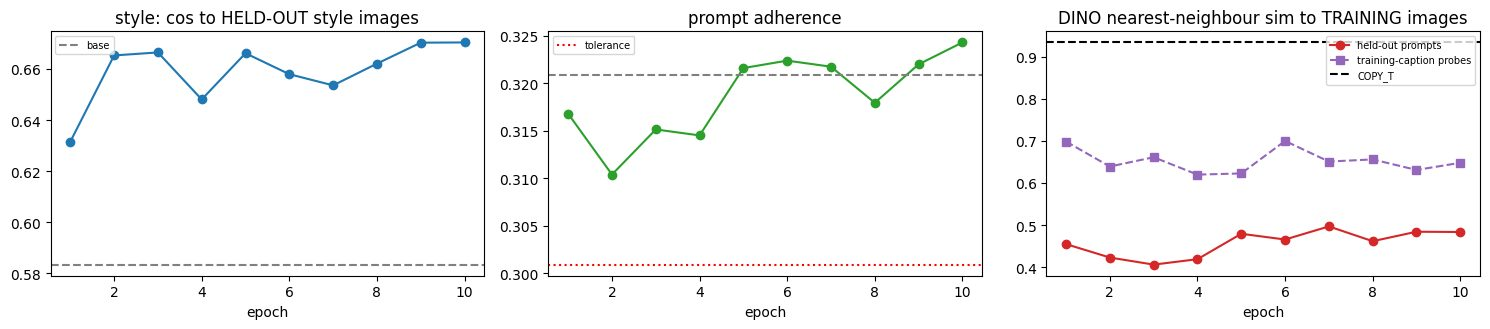

eligible epochs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] -> selected epoch 10  (passed all gates)
last epoch would have been 10: style 0.6704, copies 0


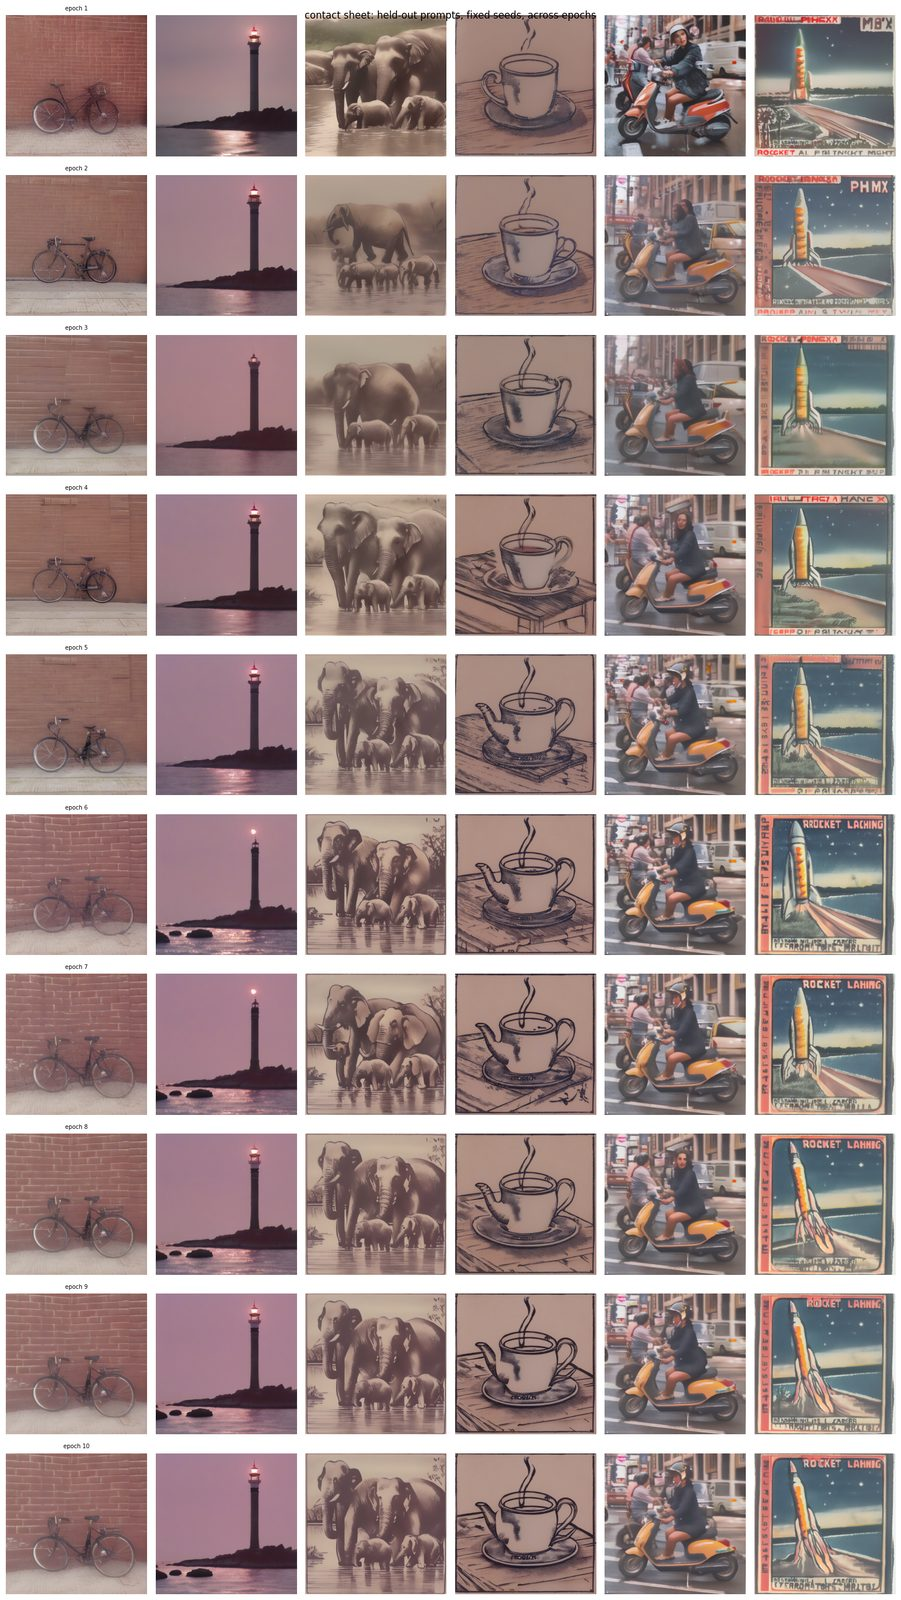

In [30]:
eps = sorted(EVALS)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].plot(eps, [EVALS[e]["style"] for e in eps], "o-"); ax[0].axhline(BASE["style"], ls="--", c="gray", label="base")
ax[0].set_title("style: cos to HELD-OUT style images")
ax[1].plot(eps, [EVALS[e]["adherence"] for e in eps], "o-", c="tab:green"); ax[1].axhline(BASE["adherence"], ls="--", c="gray")
ax[1].axhline(BASE["adherence"] - 0.02, ls=":", c="r", label="tolerance"); ax[1].set_title("prompt adherence")
ax[2].plot(eps, [EVALS[e]["nn_max"] for e in eps], "o-", c="tab:red", label="held-out prompts")
ax[2].plot(eps, [EVALS[e]["probe_nn_max"] for e in eps], "s--", c="tab:purple", label="training-caption probes")
ax[2].axhline(COPY_T, ls="--", c="k", label="COPY_T"); ax[2].set_title("DINO nearest-neighbour sim to TRAINING images")
for a in ax: a.set_xlabel("epoch"); a.legend(fontsize=7)
plt.tight_layout(); show_fig("9_checkpoint_curves")

elig = [e for e in eps if EVALS[e]["copies"] == 0 and EVALS[e]["adherence"] >= BASE["adherence"] - 0.02]
BEST_EP = max(elig, key=lambda e: EVALS[e]["style"]) if elig else \
    min(eps, key=lambda e: (EVALS[e]["copies"], -EVALS[e]["style"]))
BEST_CKPT = str(OUT / "ckpt" / f"ep{BEST_EP:02d}")
print(f"eligible epochs {elig} -> selected epoch {BEST_EP}  "
      f"({'passed all gates' if elig else 'NO checkpoint passed: least-copying fallback: treat with suspicion'})")
print(f"last epoch would have been {eps[-1]}: style {EVALS[eps[-1]]['style']:.4f}, copies {EVALS[eps[-1]]['copies']}")
_have = [e for e in eps if e in SHEETS]    # a resumed session has thumbnails only for the epochs it ran
if _have:
    sheet([SHEETS[e] for e in _have], [f"epoch {e}" for e in _have],
          "contact sheet: held-out prompts, fixed seeds, across epochs")
if "main" in getattr(unet, "peft_config", {}):
    unet.delete_adapters("main")

## 10. Reload the selected checkpoint from disk, and sweep its strength

From here on the adapter comes **from the file**, loaded the way a user would load it. The first
thing we do is re-score it at scale 1.0 against the in-memory numbers from §9.

Then the strength sweep. The usable range for a style LoRA is often 0.6 to 0.8, not 1.0. Here it is measured as a trade-off
curve (style up, adherence down), not eyeballed.

[stage] reload_check: computed in 98s -> state/reload_check.pt
reloaded epoch 10: style 0.6719 (Δ +0.0015)  adherence 0.3204 (Δ -0.0039)
the file reproduces the in-memory checkpoint (fp16 storage accounts for tiny deltas).
scale 0.0: style 0.5834  adherence 0.3209  copies 0
scale 0.4: style 0.6079  adherence 0.3186  copies 0
scale 0.6: style 0.6195  adherence 0.3154  copies 0
scale 0.8: style 0.6556  adherence 0.3163  copies 0
scale 1.0: style 0.6719  adherence 0.3204  copies 0
scale 1.2: style 0.6625  adherence 0.3116  copies 0
[stage] sweep: computed in 441s -> state/sweep.pt


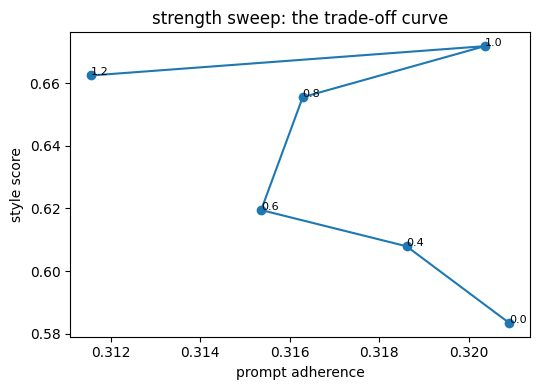

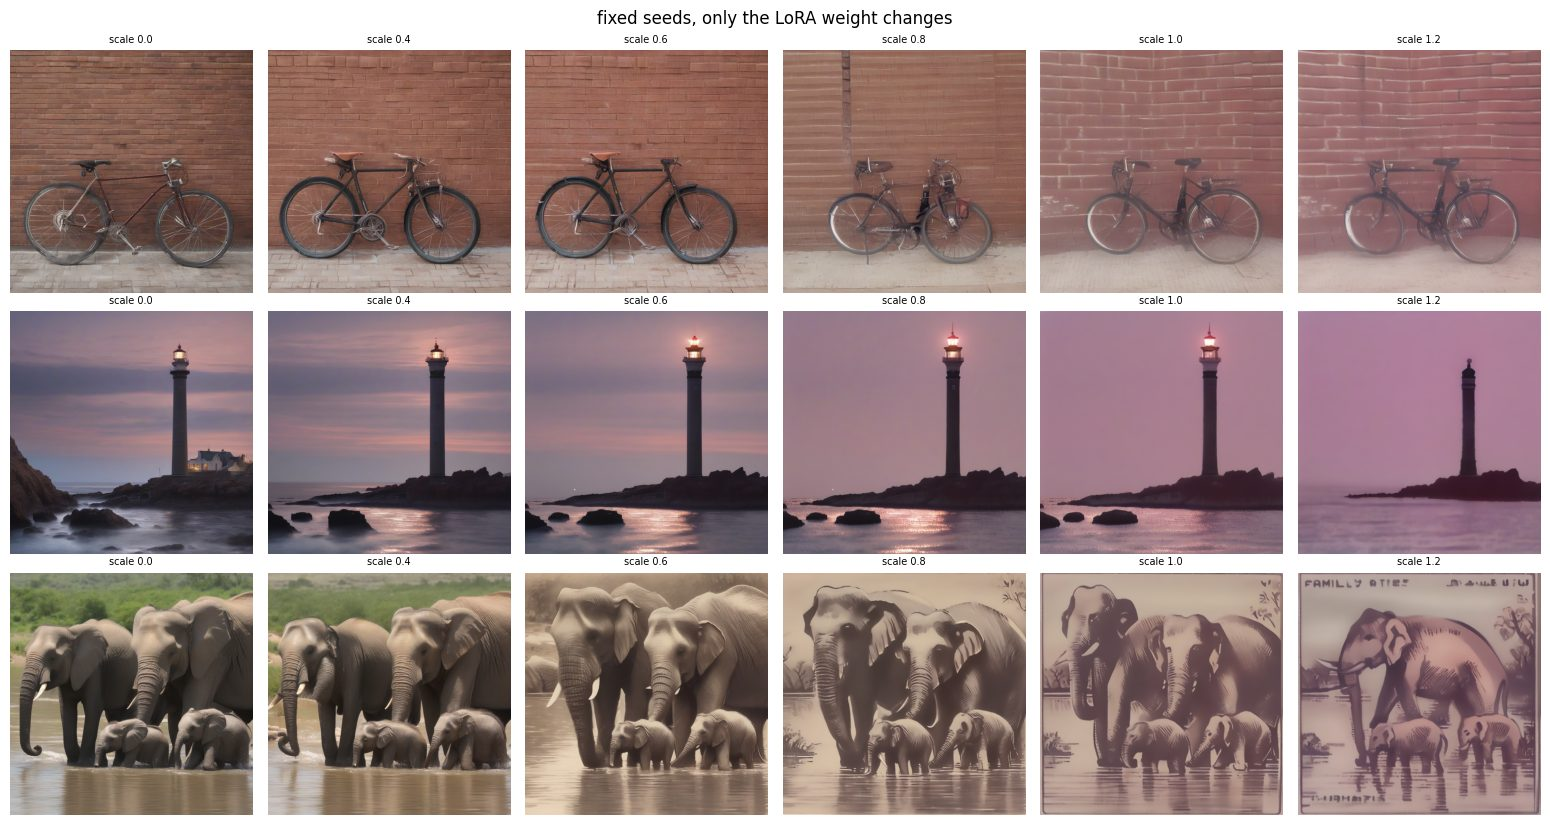

recommended default scale (max style within the adherence tolerance): 1.0


In [31]:
gen_pipe.load_lora_weights(BEST_CKPT, adapter_name="style")
gen_pipe.set_adapters(["style"], adapter_weights=[1.0])
_SW_KEY = train_fp(BEST_EP, RESOLUTION, GEN_STEPS, GUIDANCE, CHOSEN)
RELOAD = stage("reload_check",
               lambda: score(generate("held_trig", RESOLUTION), generate(f"probe_{CHOSEN}", RESOLUTION)),
               key=_SW_KEY)
d_style = RELOAD["style"] - EVALS[BEST_EP]["style"]
d_adh = RELOAD["adherence"] - EVALS[BEST_EP]["adherence"]
print(f"reloaded epoch {BEST_EP}: style {RELOAD['style']:.4f} (Δ {d_style:+.4f})  adherence {RELOAD['adherence']:.4f} (Δ {d_adh:+.4f})")
assert abs(d_style) < 0.02 and abs(d_adh) < 0.02, "reloaded adapter behaves differently: serialization bug"
print("the file reproduces the in-memory checkpoint (fp16 storage accounts for tiny deltas).")

SCALES = [0.0, 0.4, 0.6, 0.8, 1.0, 1.2]


def _sweep():
    out, rows = {}, []
    for s in SCALES:
        gen_pipe.set_adapters(["style"], adapter_weights=[s])
        imgs = generate("held_trig", RESOLUTION)
        out[s] = score(imgs); rows.append(imgs[:3])
        print(f"scale {s:.1f}: style {out[s]['style']:.4f}  adherence {out[s]['adherence']:.4f}  copies {out[s]['copies']}")
    return {"sweep": out, "rows": rows}


_sw = stage("sweep", _sweep, key=_SW_KEY + fp(SCALES))
SWEEP, sweep_rows = _sw["sweep"], _sw["rows"]
gen_pipe.set_adapters(["style"], adapter_weights=[1.0])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot([SWEEP[s]["adherence"] for s in SCALES], [SWEEP[s]["style"] for s in SCALES], "o-")
for s in SCALES:
    ax.annotate(f"{s}", (SWEEP[s]["adherence"], SWEEP[s]["style"]), fontsize=8)
ax.set_xlabel("prompt adherence"); ax.set_ylabel("style score"); ax.set_title("strength sweep: the trade-off curve")
plt.tight_layout(); show_fig("10_strength_sweep_curve")
sheet([list(r) for r in zip(*sweep_rows)], [[f"scale {s}" for s in SCALES]] * 3, "fixed seeds, only the LoRA weight changes")
REC_SCALE = max([s for s in SCALES if s > 0 and SWEEP[s]["adherence"] >= BASE["adherence"] - 0.02 and SWEEP[s]["copies"] == 0]
                or [0.6], key=lambda s: SWEEP[s]["style"])
print(f"recommended default scale (max style within the adherence tolerance): {REC_SCALE}")

## 11. Export for the tools people actually use

What `StableDiffusionXLPipeline.save_lora_weights` in diffusers 0.40.0 actually does, read from
its source:

* it **does not convert keys**. It prefixes each key you pass with `unet.` (`pack_weights`) and
  writes `pytorch_lora_weights.safetensors` unless you give `weight_name`;
* with `unet_lora_adapter_metadata=` it stores the LoRA config as JSON under the safetensors
  header key `lora_adapter_metadata`, which the loader uses to rebuild `LoraConfig`, **alpha
  included**. Without metadata or alpha tensors, the loader assumes `lora_alpha = r` (scale 1.0).

The kohya-style format (`lora_unet_…` keys, `lora_down`/`lora_up`, a per-module `.alpha`) is
produced by `diffusers.utils.convert_state_dict_to_kohya`. Its docstring says the output "can
be used in AUTOMATIC1111, ComfyUI, SD.Next, InvokeAI, etc." That is the library's claim, and we
did not test those UIs. Read from its source, it writes **`alpha = rank`** for every module. So a
LoRA trained with `lora_alpha ≠ r` silently changes strength in the kohya file. We trained at
`alpha == r`, and the code below asserts it and rewrites alpha if you changed that.

The proof of both files is a round trip: load each back into the pipeline and check that the
**weights and scalings are identical**, and so are the pixels.

In [32]:
from safetensors.torch import load_file, save_file
from safetensors import safe_open
from diffusers.utils import convert_state_dict_to_kohya

EXPORT = OUT / "export"; EXPORT.mkdir(exist_ok=True)
NAME = f"{TRIGGER}_style_sdxl_ep{BEST_EP:02d}"
sd_diff = load_file(f"{BEST_CKPT}/pytorch_lora_weights.safetensors")          # 'unet.…lora_A.weight'
with safe_open(f"{BEST_CKPT}/pytorch_lora_weights.safetensors", "pt") as f:
    hdr = f.metadata() or {}
lora_meta = json.loads(hdr["lora_adapter_metadata"]) if "lora_adapter_metadata" in hdr else None
print(f"checkpoint: {len(sd_diff)} tensors; first keys:", list(sd_diff)[:2])
print(f"header keys: {list(hdr)}   stored r/alpha: "
      f"{(lora_meta or {}).get('unet.r')}/{(lora_meta or {}).get('unet.lora_alpha')}")

INFO = {"trigger_word": TRIGGER, "base_model": MODEL_ID, "network_dim": str(RANK), "network_alpha": str(LORA_ALPHA),
        "recommended_scale": str(REC_SCALE), "training_images": str(len(TRAIN)),
        "dataset": DATA_SOURCE, "dataset_licence": DATA_LICENCE,
        "credit": CREDIT, "caption_strategy": CHOSEN}

# (a) diffusers format: same tensors, human name, same adapter metadata + our info
diff_path = EXPORT / f"{NAME}_diffusers.safetensors"
save_file(sd_diff, str(diff_path), metadata={**hdr, **INFO})

# (b) kohya format
sd_k = convert_state_dict_to_kohya(sd_diff)
alphas = {k: v for k, v in sd_k.items() if k.endswith(".alpha")}
wrong = {k for k, v in alphas.items() if float(v) != float(LORA_ALPHA)}
print(f"kohya: {len(sd_k)} tensors, {len(alphas)} alphas; alphas != lora_alpha before fix: {len(wrong)}")
for k in alphas:                       # the converter writes int64 alpha = rank; store the TRUE alpha, float
    sd_k[k] = torch.tensor(float(LORA_ALPHA), dtype=torch.float32)
kohya_path = EXPORT / f"{NAME}_kohya.safetensors"
save_file({k: v.contiguous() for k, v in sd_k.items()}, str(kohya_path), metadata={"format": "pt", **INFO})
print("kohya first keys:", [k for k in sd_k][:3])
for p in [diff_path, kohya_path]:
    print(f"   {p.name:<52} {p.stat().st_size/1e6:6.1f} MB")

checkpoint: 1120 tensors; first keys: ['unet.down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_k.lora_A.weight', 'unet.down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_k.lora_B.weight']
header keys: ['format', 'lora_adapter_metadata']   stored r/alpha: 16/16
kohya: 1680 tensors, 560 alphas; alphas != lora_alpha before fix: 0
kohya first keys: ['lora_unet_down_blocks_1_attentions_0_transformer_blocks_0_attn1_to_k.lora_down.weight', 'lora_unet_down_blocks_1_attentions_0_transformer_blocks_0_attn1_to_k.alpha', 'lora_unet_down_blocks_1_attentions_0_transformer_blocks_0_attn1_to_k.lora_up.weight']
   phlmx_style_sdxl_ep10_diffusers.safetensors            46.6 MB
   phlmx_style_sdxl_ep10_kohya.safetensors                46.7 MB


In [33]:
gen_pipe.delete_adapters(["style"])
gen_pipe.load_lora_weights(str(EXPORT), weight_name=diff_path.name, adapter_name="diff")
gen_pipe.load_lora_weights(str(EXPORT), weight_name=kohya_path.name, adapter_name="kohya")

n_cmp, n_bad = 0, 0
for mod in unet.modules():
    if hasattr(mod, "lora_A") and "diff" in mod.lora_A and "kohya" in mod.lora_A:
        n_cmp += 1
        same = (torch.equal(mod.lora_A["diff"].weight, mod.lora_A["kohya"].weight) and
                torch.equal(mod.lora_B["diff"].weight, mod.lora_B["kohya"].weight) and
                math.isclose(mod.scaling["diff"], mod.scaling["kohya"]))
        n_bad += not same
print(f"adapted modules compared: {n_cmp}   mismatched: {n_bad}")
assert n_cmp == MAIN["adapters"] and n_bad == 0, "the two export formats do not load to the same LoRA"

px = {}
for a in ["diff", "kohya"]:
    gen_pipe.set_adapters([a], adapter_weights=[1.0])
    px[a] = np.asarray(generate("held_trig", RESOLUTION)[0], dtype=np.float32)
PIX_DIFF = float(np.abs(px["diff"] - px["kohya"]).mean())
print(f"mean |pixel difference| between the two files' generations: {PIX_DIFF:.3f} / 255")
print(f"""
Both files load to bit-identical adapter weights and scalings. Ship {kohya_path.name} for
kohya-lineage UIs and {diff_path.name} for diffusers (pipe.load_lora_weights). Recommended weight
{REC_SCALE}; trigger '{TRIGGER}' at the START of the prompt.

For the post's actual base model the export API is the same shape: QwenImagePipeline in diffusers
0.40.0 has save_lora_weights(save_directory, transformer_lora_layers=..., ...), because the
adapter targets its transformer rather than a U-Net.""")

adapted modules compared: 560   mismatched: 0
mean |pixel difference| between the two files' generations: 0.000 / 255

Both files load to bit-identical adapter weights and scalings. Ship phlmx_style_sdxl_ep10_kohya.safetensors for
kohya-lineage UIs and phlmx_style_sdxl_ep10_diffusers.safetensors for diffusers (pipe.load_lora_weights). Recommended weight
1.0; trigger 'phlmx' at the START of the prompt.

For the post's actual base model the export API is the same shape: QwenImagePipeline in diffusers
0.40.0 has save_lora_weights(save_directory, transformer_lora_layers=..., ...), because the
adapter targets its transformer rather than a U-Net.


## 12. The card

In [34]:
def sh(c):
    try:
        return subprocess.check_output(c, shell=True, text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return None


import diffusers, transformers, peft
CARD = {
    "context": f"style LoRA on SDXL from a small curated set ({DATA_NAME}); workflow after the 'desi-max' post",
    "data_name": DATA_NAME, "output_dir": str(OUT),
    "base_model": MODEL_ID, "vae": VAE_ID, "quick_mode": QUICK,
    "dataset": DATA_SOURCE, "dataset_licence": DATA_LICENCE, "credit": CREDIT,
    "selection": {"stage": STAGE, "shards_scanned": len(files), "row_groups_fetched": len(chosen),
                  "network_mb": round(fetched_mb, 1), "fetched": len(records),
                  "exact_dups": len(records) - len(uniq), "near_dup_groups": len(dups),
                  "train": len(TRAIN), "holdout": len(HOLD), "south_asian_train": sum(r["region"] for r in TRAIN),
                  "record_ids_train": [r["record_id"] for r in TRAIN]},
    "copy_threshold_dino": COPY_T, "dedup_and_memorisation_model": DINO_ID,
    "resolution": RESOLUTION, "resolution_table_upscaled_frac": res_table, "bucket_step": STEP,
    "buckets_used": {str(k): v for k, v in Counter(bk_of).items()},
    "captioner": CAPTIONER_ID, "caption_task": TASK, "trigger": TRIGGER,
    "caption_ablation": ABL, "caption_strategy": CHOSEN,
    "schedule": {"repeats": REPEATS, "epochs": EPOCHS, "batch": BATCH, "grad_acc": GRAD_ACC,
                 "steps": MAIN["steps"], "views_per_image": REPEATS * EPOCHS, "lr": LR,
                 "rank": RANK, "alpha": LORA_ALPHA, "targets": LORA_TARGETS, "min_snr_gamma": 5.0},
    "baseline": BASE, "evals": EVALS, "selected_epoch": BEST_EP, "reload": RELOAD,
    "strength_sweep": SWEEP, "recommended_scale": REC_SCALE,
    "export": {"diffusers": diff_path.name, "kohya": kohya_path.name, "kohya_alpha_fixed": len(wrong),
               "roundtrip_modules": n_cmp, "roundtrip_mismatch": n_bad, "pixel_diff": PIX_DIFF},
    "train_minutes": round(MAIN["seconds"] / 60, 1), "peak_vram_gib": round(MAIN["peak_gib"], 3),
    "git_sha": sh("git rev-parse HEAD"), "git_dirty": bool(sh("git status --porcelain")),
    "versions": {"torch": torch.__version__, "diffusers": diffusers.__version__,
                 "transformers": transformers.__version__, "peft": peft.__version__},
}
json.dump(CARD, open(OUT / "CARD.json", "w"), indent=2, default=str)
shutil.copy(OUT / "CARD.json", EXPORT / f"{NAME}_CARD.json")         # the card travels with the file
print(json.dumps(CARD, indent=2, default=str)[:2000])

{
  "context": "style LoRA on SDXL from a small curated set (matchbox_india); workflow after the 'desi-max' post",
  "data_name": "matchbox_india",
  "output_dir": "/content/drive/MyDrive/finetune_runs/55_run2",
  "base_model": "stabilityai/stable-diffusion-xl-base-1.0",
  "vae": "madebyollin/sdxl-vae-fp16-fix",
  "quick_mode": false,
  "dataset": "local folder /content/desi_repo/finetune/notebooks/data/matchbox_india",
  "dataset_licence": "unspecified",
  "credit": "",
  "selection": {
    "stage": "own folder",
    "shards_scanned": 0,
    "row_groups_fetched": 0,
    "network_mb": 0.0,
    "fetched": 197,
    "exact_dups": 0,
    "near_dup_groups": 0,
    "train": 189,
    "holdout": 8,
    "south_asian_train": 0,
    "record_ids_train": [
      "mb_136.jpg",
      "mb_004.jpg",
      "mb_174.jpg",
      "mb_108.jpg",
      "mb_150.jpg",
      "mb_147.jpg",
      "mb_052.jpg",
      "mb_134.jpg",
      "mb_015.jpg",
      "mb_066.jpg",
      "mb_030.jpg",
      "mb_099.jpg",
      

## 13. Generate images with the trained LoRA

The exported diffusers file from §11 is loaded into a **full** SDXL pipeline (with its text
encoders, which training freed), so any prompt works. Every image and grid is saved to `GEN_DIR`
(`<output folder>/generations`), named after the prompt and its settings, so any image can be
regenerated exactly.

**To generate without training:** run the cells of §0 (they set the trigger and `OUT`), then jump
here. The next cell uses the newest LoRA exported to `OUT/export`; if there is none, it downloads
the published one from [spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator](https://huggingface.co/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator) (`sdxl/`).

**Prompts** follow the training captions: `<trigger>, a matchbox, <what is shown>, <background
colour>, headline '<1 or 2 words>', text '<maker>'`. The caption cleanup in §5.2 removes the word
"label", so the captions read "a matchbox, ...". Style words ("vintage", "retro") are not needed:
the trigger carries the style. SDXL often misspells lettering, so keep headlines to one or two
short English words.

| setting | meaning |
|---|---|
| `scale` | LoRA strength: 0.0 = base model; the card's `recommended_scale` (§10) is the default |
| `seed` | a fixed number = the same image again; `None` = a new random image (the seed is printed) |
| `w`, `h` | size; SDXL's sizes of about 1 megapixel below give the best results |
| `steps`, `cfg` | denoising steps (30) and prompt strictness (6.0; try 5 to 7) |


In [35]:
import glob
from diffusers import StableDiffusionXLPipeline, AutoencoderKL
from diffusers.utils import make_image_grid
from IPython.display import display
from PIL import ImageDraw, ImageFont

# free whatever training left on the GPU (no-ops after a restart)
for _n in ["gen_pipe", "unet", "vae", "clip", "dino", "cap_model", "pipe"]:
    globals().pop(_n, None)
gc.collect()
if DEV == "cuda":
    torch.cuda.empty_cache()

HF_MODEL = "spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator"     # the published weights
_lora = sorted(glob.glob(str(OUT / "export" / "*_diffusers.safetensors")), key=os.path.getmtime)
_ck = sorted((OUT / "ckpt").glob("ep*/*.safetensors"), key=lambda q: q.parent.name)
_card = OUT / "CARD.json"
if _lora:                          # this run's export (§11)
    LORA_FILE = Path(_lora[-1])
elif _ck:                          # §11 never ran: fall back to the newest raw epoch checkpoint
    LORA_FILE = _ck[-1]
    print(f"no export found; falling back to {LORA_FILE.parent.name}. That epoch has NOT been through "
          f"§9's selection gates, so check it for memorisation before trusting it.")
else:                              # nothing trained here: use the published LoRA from the Hub
    from huggingface_hub import hf_hub_download
    LORA_FILE = Path(hf_hub_download(HF_MODEL, "sdxl/phlmx_style_sdxl_ep10_diffusers.safetensors"))
    _card = Path(hf_hub_download(HF_MODEL, "sdxl/CARD.json"))
REC = float(json.load(open(_card)).get("recommended_scale", 0.8)) if _card.exists() else 0.8
print(f"LoRA {LORA_FILE.name} | trigger {TRIGGER!r} | recommended scale {REC} | images -> {GEN_DIR}")

_kw = dict(dtype=DTYPE)
if VAE_ID:
    _kw["vae"] = AutoencoderKL.from_pretrained(VAE_ID, dtype=DTYPE)
if not QUICK:
    _kw.update(variant="fp16", use_safetensors=True)
ipipe = StableDiffusionXLPipeline.from_pretrained(MODEL_ID, **_kw).to(DEV)
ipipe.load_lora_weights(str(LORA_FILE.parent), weight_name=LORA_FILE.name, adapter_name="lora")
ipipe.set_progress_bar_config(disable=True)

NEG = "photograph, photorealistic, 3d render, blurry, low quality, watermark"
W0, H0 = (64, 64) if QUICK else (832, 1216)                    # QUICK: tiny pipe, tiny images
STEPS0 = 2 if QUICK else 30
LEAD = "a matchbox, " if DATA_NAME == "matchbox_india" else ""


def P(body):
    """'<trigger>, a matchbox, <body>': the training captions' shape."""
    return f"{TRIGGER}, {LEAD}{body}"


def _slug(t, n=60):
    return re.sub(r"[^a-z0-9]+", "_", t.lower()).strip("_")[:n]


def _one(prompt, scale, seed, w, h, steps, cfg, neg):
    ipipe.set_adapters(["lora"], adapter_weights=[scale])
    return ipipe(prompt, negative_prompt=NEG if neg is None else neg, width=w, height=h,
                 num_inference_steps=steps, guidance_scale=cfg,
                 generator=torch.Generator(DEV).manual_seed(seed)).images[0]


def gen(prompt, seeds=(1, 2, 3, 4), scale=REC, w=W0, h=H0, steps=STEPS0, cfg=6.0, neg=None):
    """A row of images, one per seed; saved as one grid."""
    g = make_image_grid([_one(prompt, scale, s, w, h, steps, cfg, neg) for s in seeds], rows=1, cols=len(seeds))
    g.save(GEN_DIR / f"{_slug(prompt)}_s{scale}_{w}x{h}.png")
    return g


def gen_one(prompt, scale=REC, seed=None, w=W0, h=H0, steps=STEPS0, cfg=6.0, neg=None):
    """One full-resolution image; seed=None picks a random seed and prints it."""
    seed = random.randint(0, 2**31 - 1) if seed is None else seed
    img = _one(prompt, scale, seed, w, h, steps, cfg, neg)
    name = f"{_slug(prompt)}_s{scale}_seed{seed}_{w}x{h}.png"
    img.save(GEN_DIR / name)
    print(f"seed {seed}  scale {scale}  {w}x{h}  steps {steps}  cfg {cfg}  -> {name}")
    return img


def _font(size=22):
    try:
        return ImageFont.load_default(size=size)
    except TypeError:                      # older Pillow: fixed small font
        return ImageFont.load_default()


def strength_grid(prompt, scales=(0.0, 0.6, 0.8, 1.0), seeds=(1, 2, 3), w=W0, h=H0, steps=STEPS0, cfg=6.0, thumb=384):
    """Rows = LoRA strength (0.0 = base model), columns = seeds: differences down a column are the LoRA's."""
    rows = [[_one(prompt, sc, s, w, h, steps, cfg, None) for s in seeds] for sc in scales]
    tw, th, pad = thumb, round(thumb * h / w), 34
    grid = Image.new("RGB", (len(seeds) * tw, len(scales) * (th + pad)), "white")
    d, f = ImageDraw.Draw(grid), _font()
    for r, (sc, imgs) in enumerate(zip(scales, rows)):
        for c, (s, im) in enumerate(zip(seeds, imgs)):
            grid.paste(im.resize((tw, th), Image.LANCZOS), (c * tw, r * (th + pad) + pad))
            d.text((c * tw + 8, r * (th + pad) + 6), f"scale {sc}   seed {s}", fill="black", font=f)
    grid.save(GEN_DIR / f"strength_{_slug(prompt)}_{w}x{h}.png")
    return grid

LoRA phlmx_style_sdxl_ep10_diffusers.safetensors | trigger 'phlmx' | recommended scale 1.0 | images -> /content/drive/MyDrive/finetune_runs/55_run2/generations


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

### 13.1 A batch of prompts (4 seeds each)

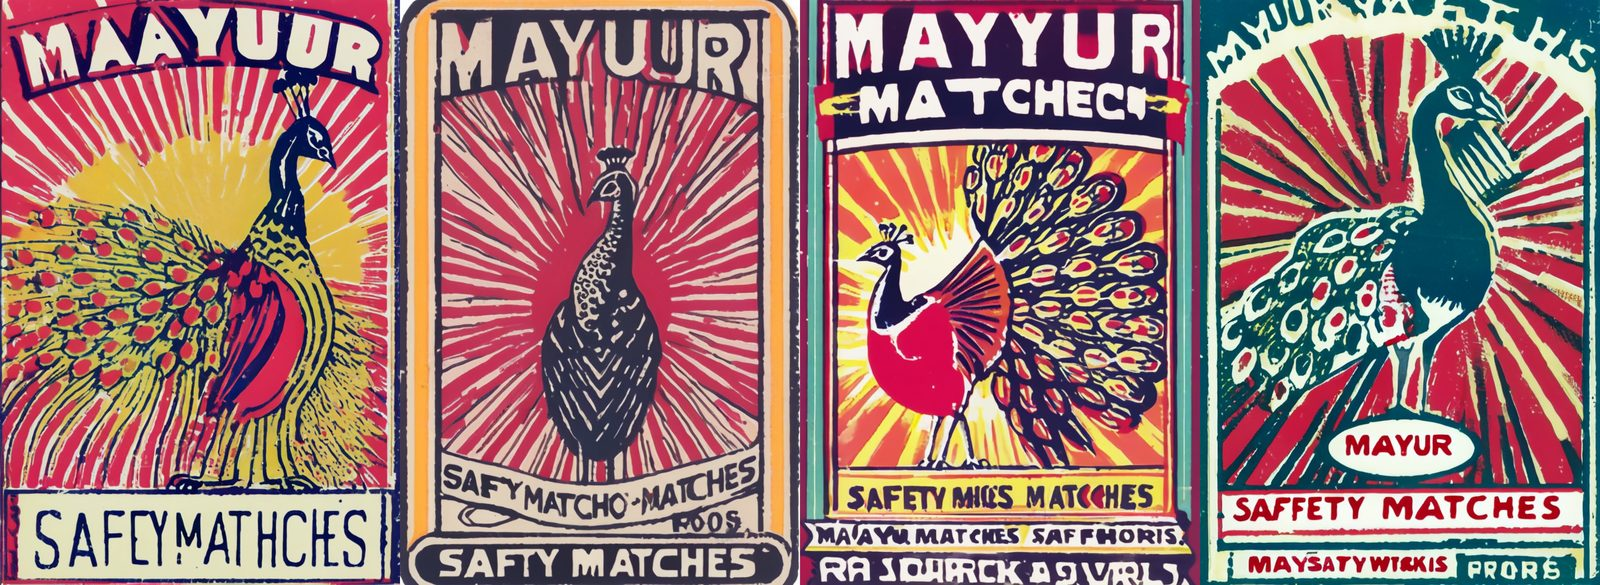

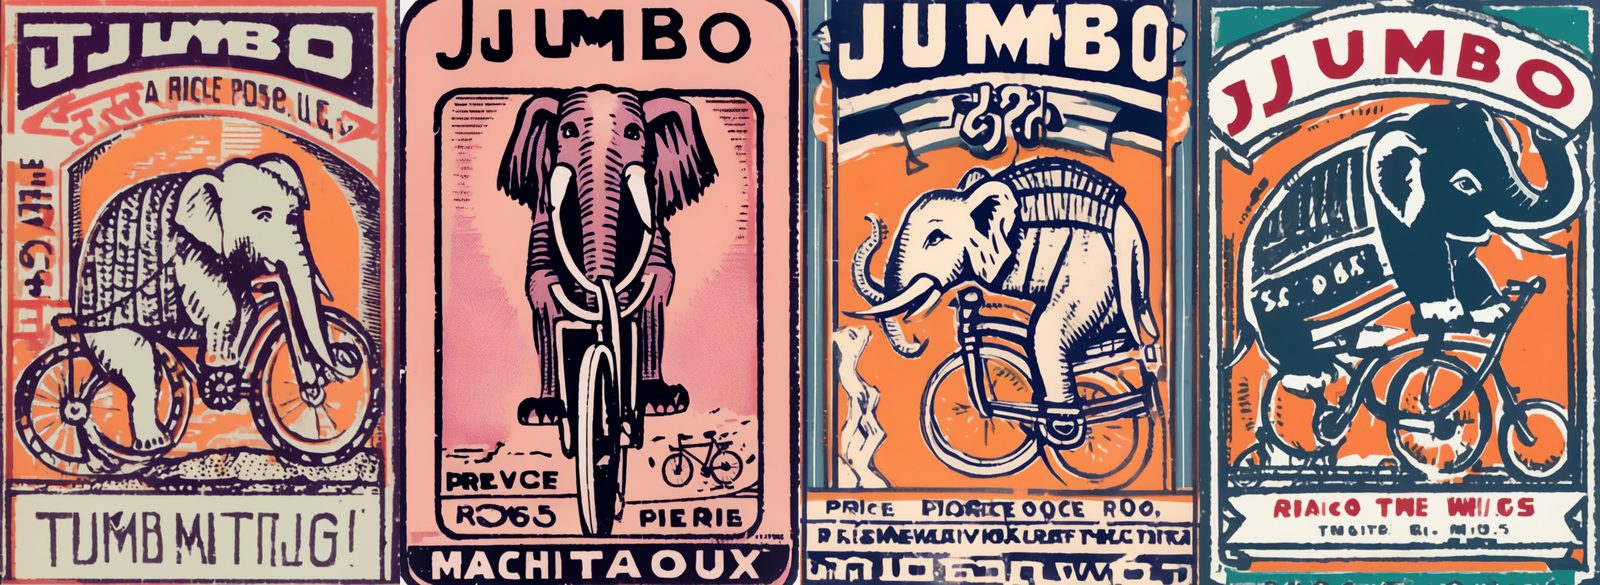

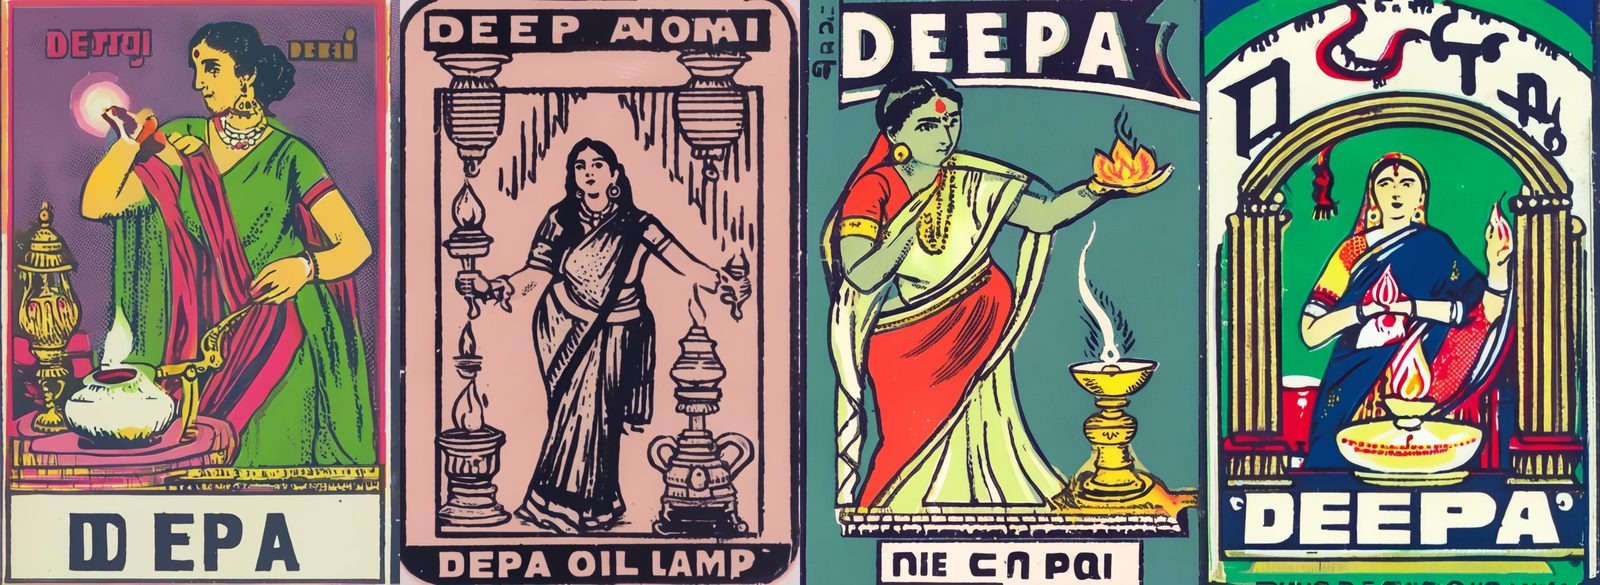

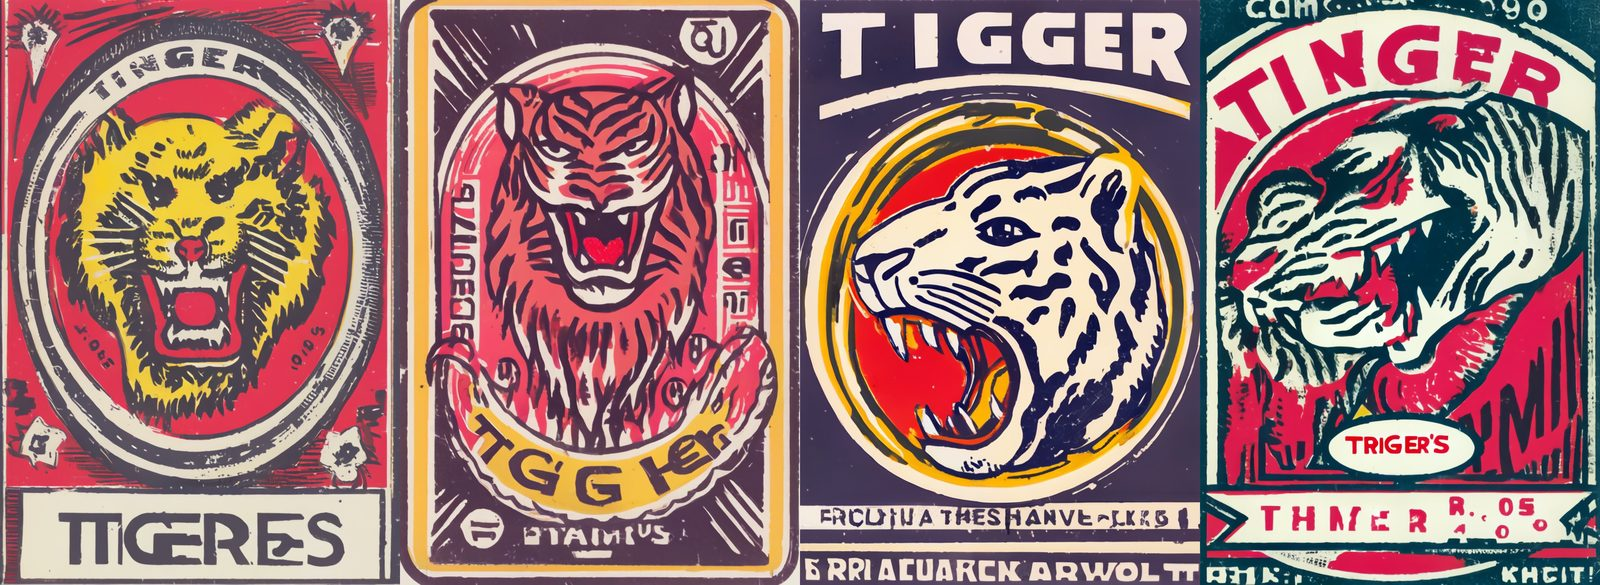

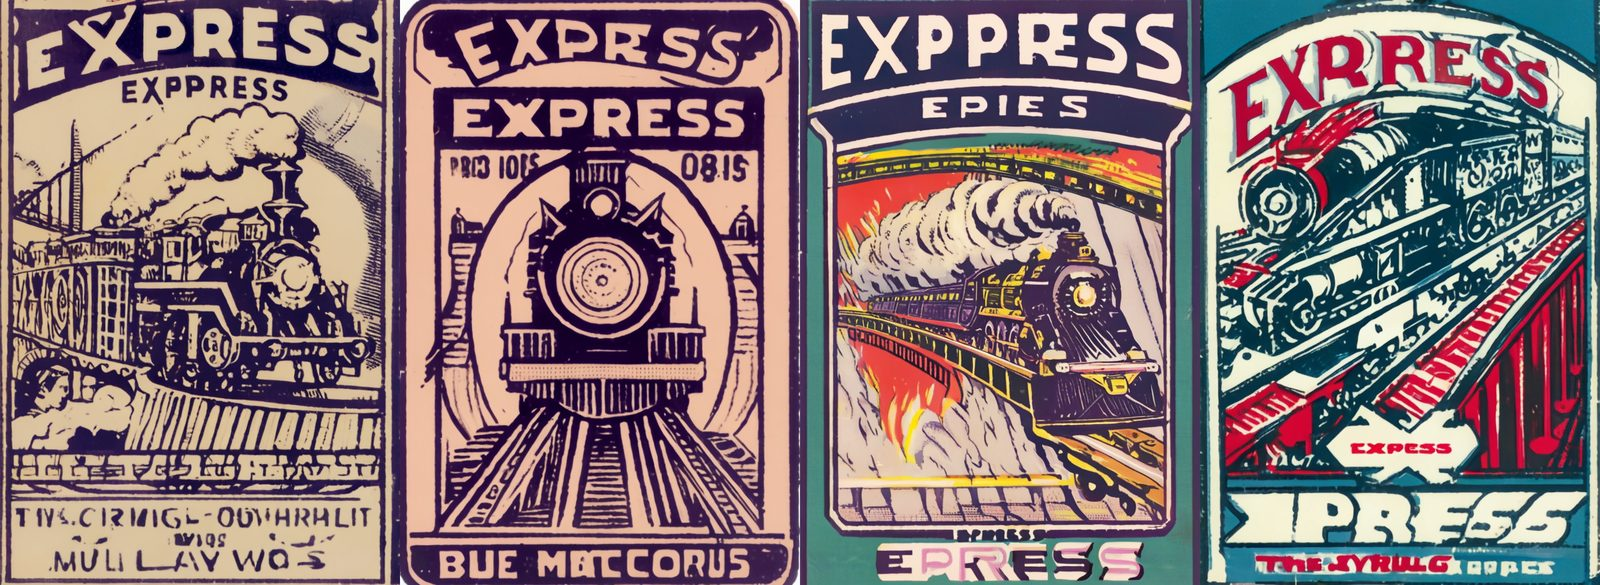

Buffered data was truncated after reaching the output size limit.

In [36]:
PROMPTS = [
    "a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR', text 'Safety Matches'",
    "a cartoon elephant riding a bicycle, orange background, headline 'JUMBO'",
    "a woman in a green sari lighting a brass oil lamp, blue background, headline 'DEEPA'",
    "a roaring tiger's head inside a yellow circle, red background, headline 'TIGER'",
    "a steam locomotive crossing a bridge, blue background, headline 'EXPRESS'",
    "a tortoise with a rabbit in front of a red sunburst, orange background, headline 'RACE', text 'Safety Matches'",
    "a cat drinking milk, blue background, headline 'PUSSY'",
    "a baby in a green dress playing with a ball, yellow background, headline 'TOM'",
    "an eagle hunting a snake inside a yellow circle, blue background, headline 'HUNTED'",
    "an aeroplane crossing a mountain, white background, headline 'EXPRESS'",
    "a gun and a sword crossed behind a pen, red background, headline 'MIGHTY', text 'Safety Matches'",
    "a boy and a girl under a crescent moon, blue background, headline 'LOVE', text 'Safety Matches'",
    "a burning aeroplane inside an orange circle, red background, headline 'FIRE', text 'Safety Matches'",
]
for p in (PROMPTS[:1] if QUICK else PROMPTS):
    display(gen(P(p)))
display(gen(P("two parrots on a branch under a crescent moon, red background, headline 'LOVE BIRDS'"), w=H0, h=W0))
display(gen(P("two snakes on a rock under a crescent moon, red background, headline 'LOVE SNAKES'"), w=H0, h=W0))

### 13.2 What the LoRA adds: strength 0.0 (base model) to 1.0, same seeds

Pick the lowest strength where the label look is clearly there and the objects still match the
prompt. If 1.0 starts copying a training label or ignoring the subject, use less.

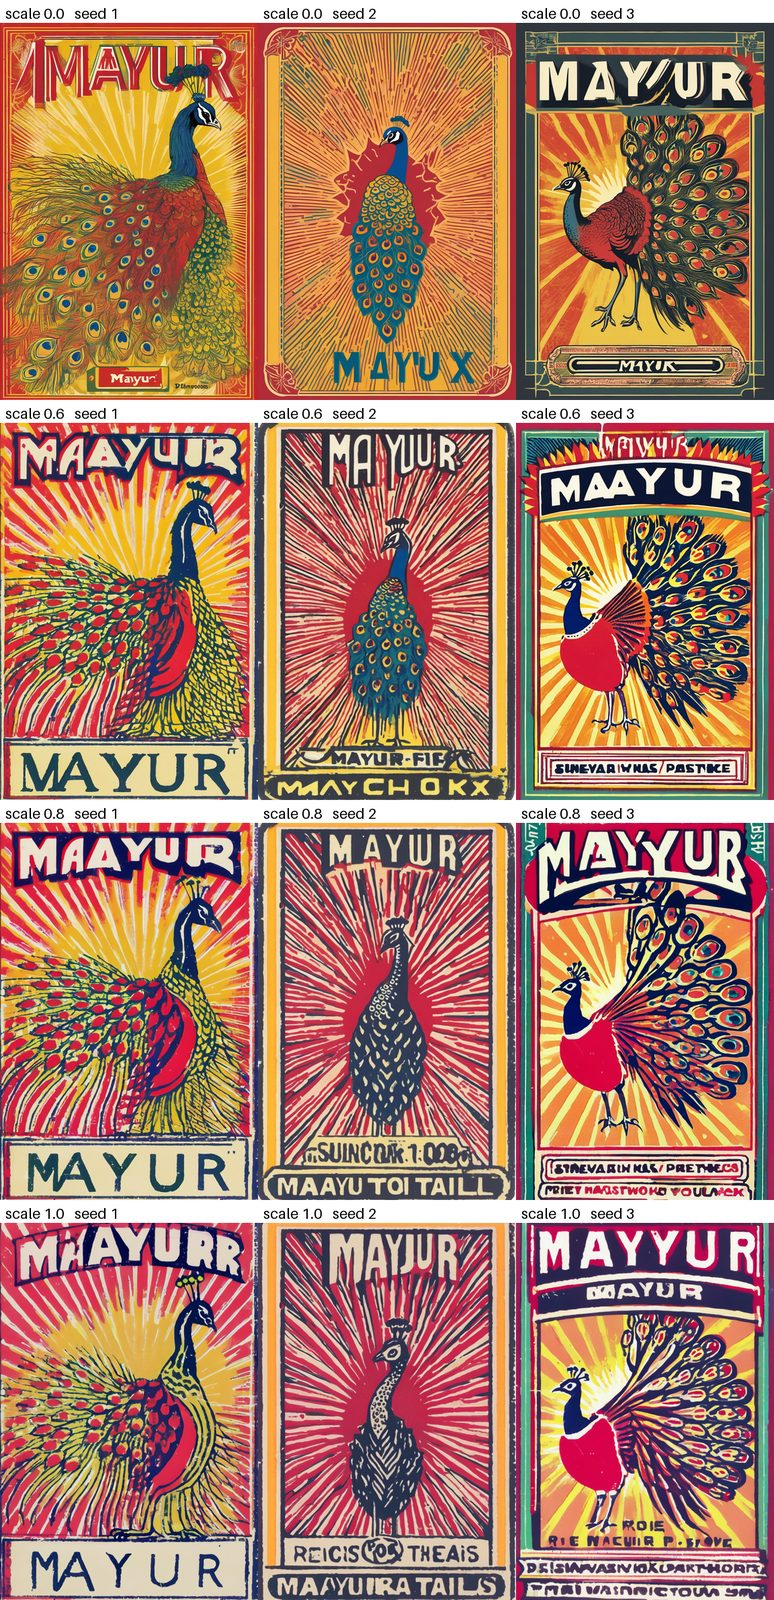

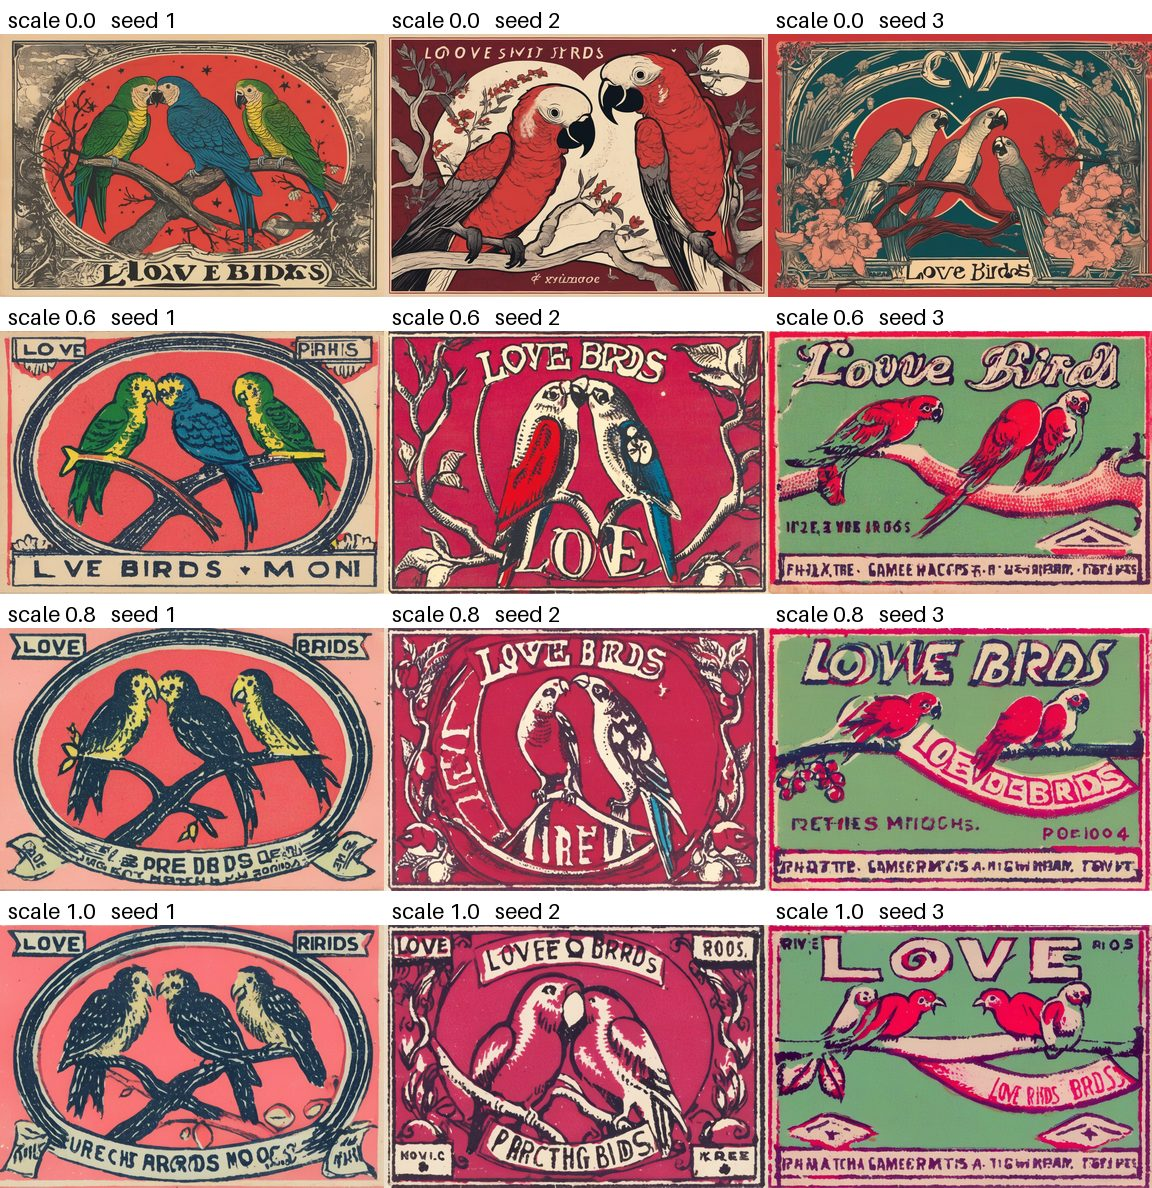

In [37]:
display(strength_grid(P("a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR'")))
if not QUICK:
    display(strength_grid(P("two parrots on a branch under a crescent moon, red background, headline 'LOVE BIRDS'"),
                          w=1216, h=832))

### 13.3 Sizes: match the shape to the subject

SDXL's ~1-megapixel sizes (multiples of 64). Most matchbox labels are tall (about 0.66 wide : 1
high), so 832 × 1216 is the default; use wide sizes for side-on animals, vehicles and scenes.

| shape | w × h | for |
|---|---|---|
| square | 1024 × 1024 | square labels |
| slightly tall | 896 × 1152 | stout portrait labels |
| **tall** | **832 × 1216** | most matchbox labels |
| very tall | 768 × 1344 | narrow labels, posters |
| slightly wide | 1152 × 896 | |
| **wide** | **1216 × 832** | landscape labels |
| very wide | 1344 × 768 | strip labels |

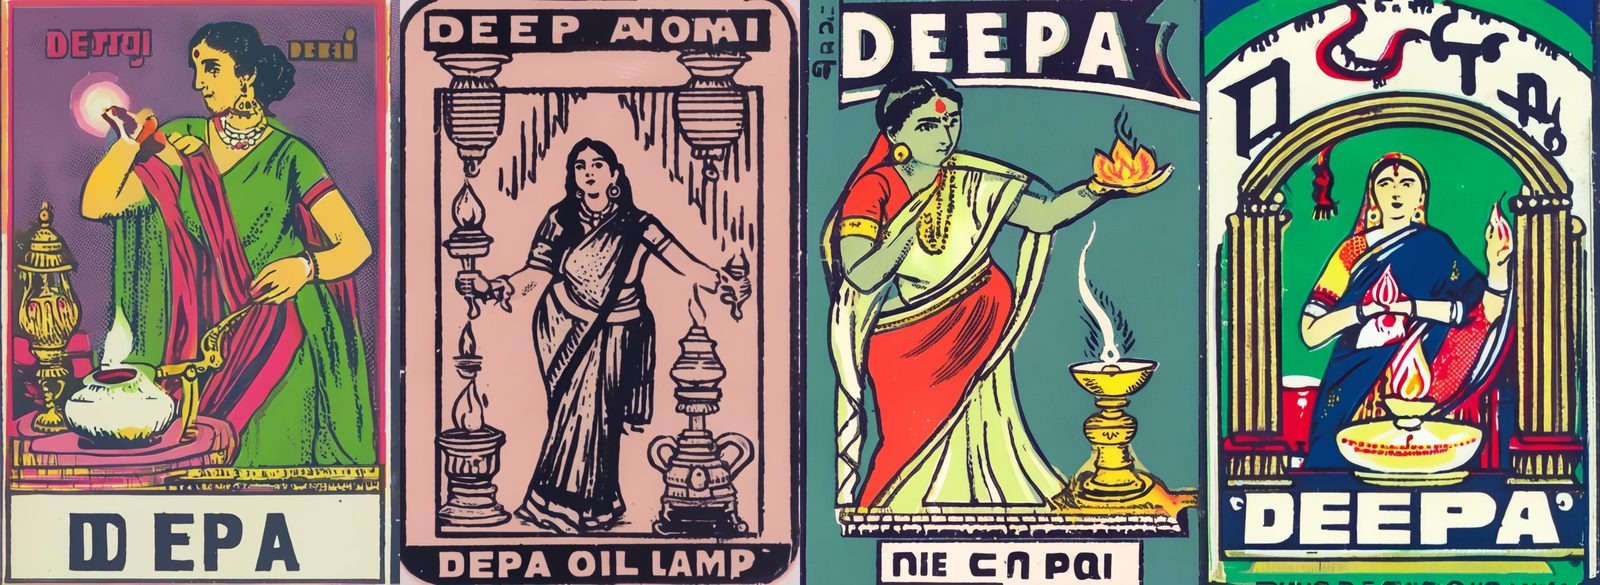

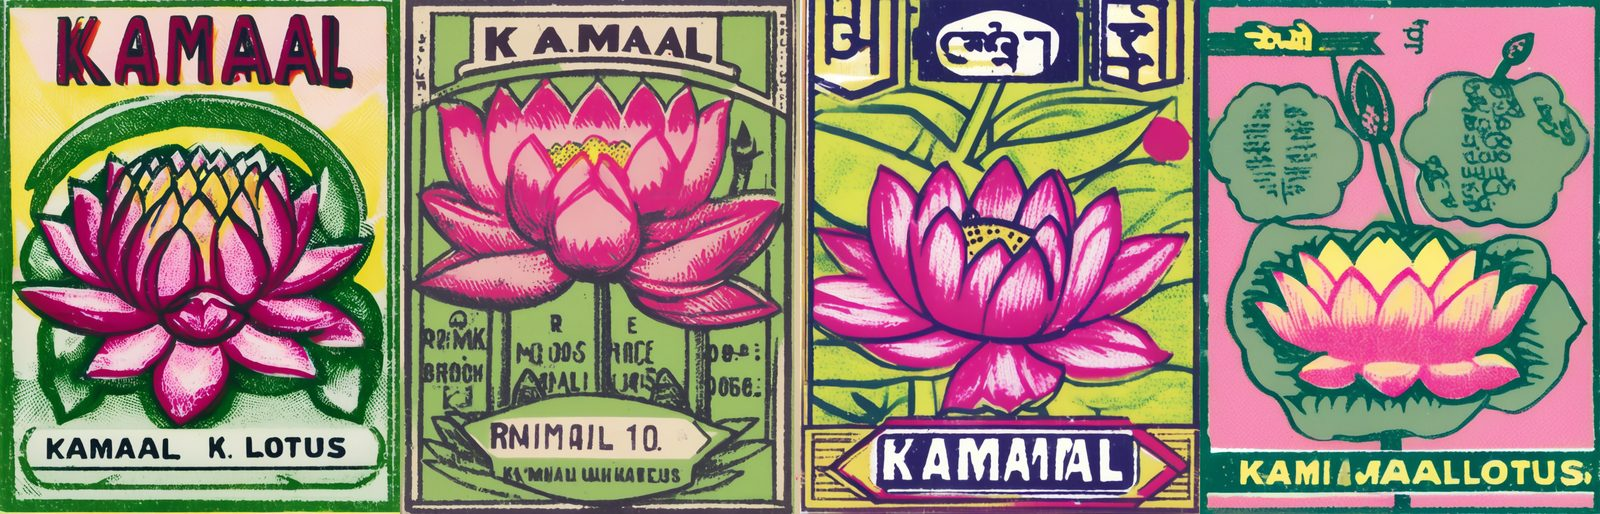

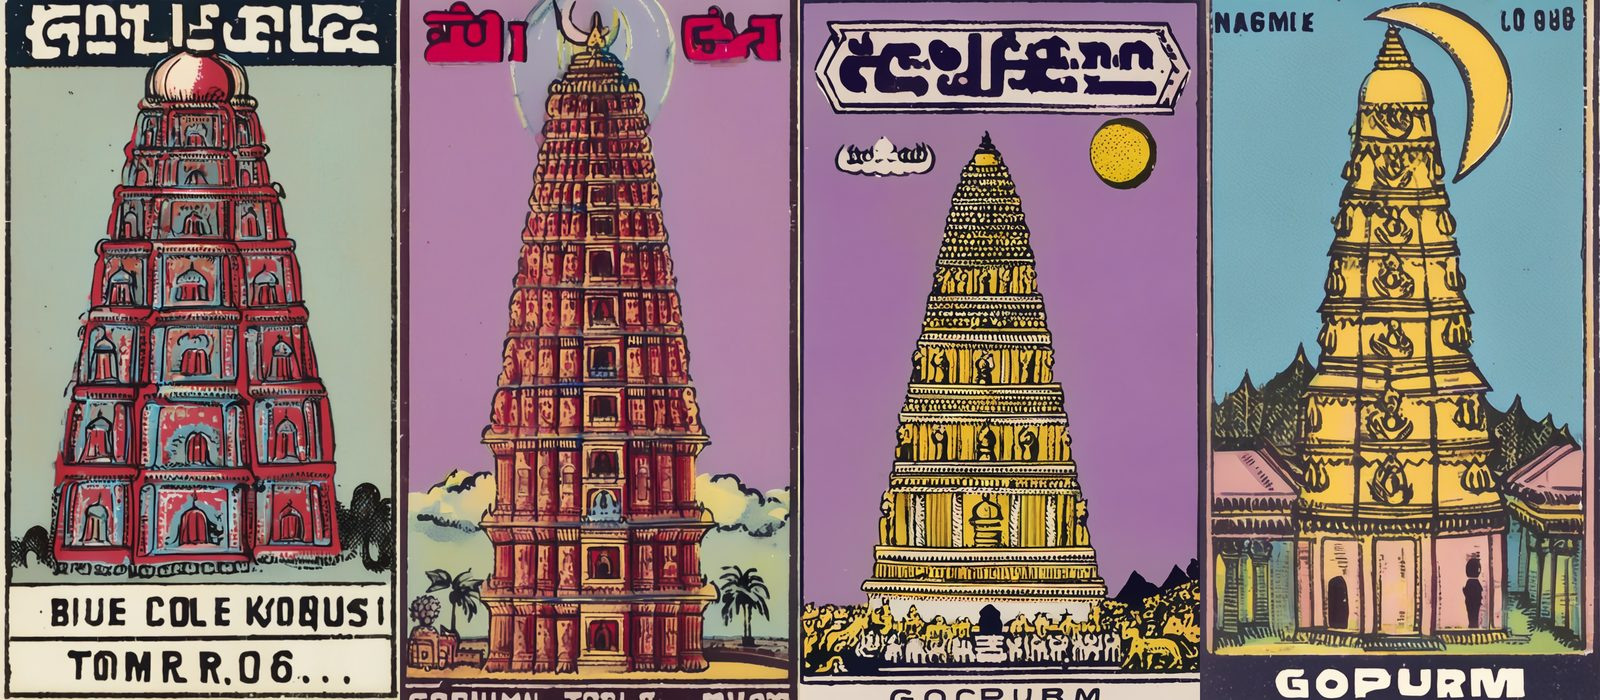

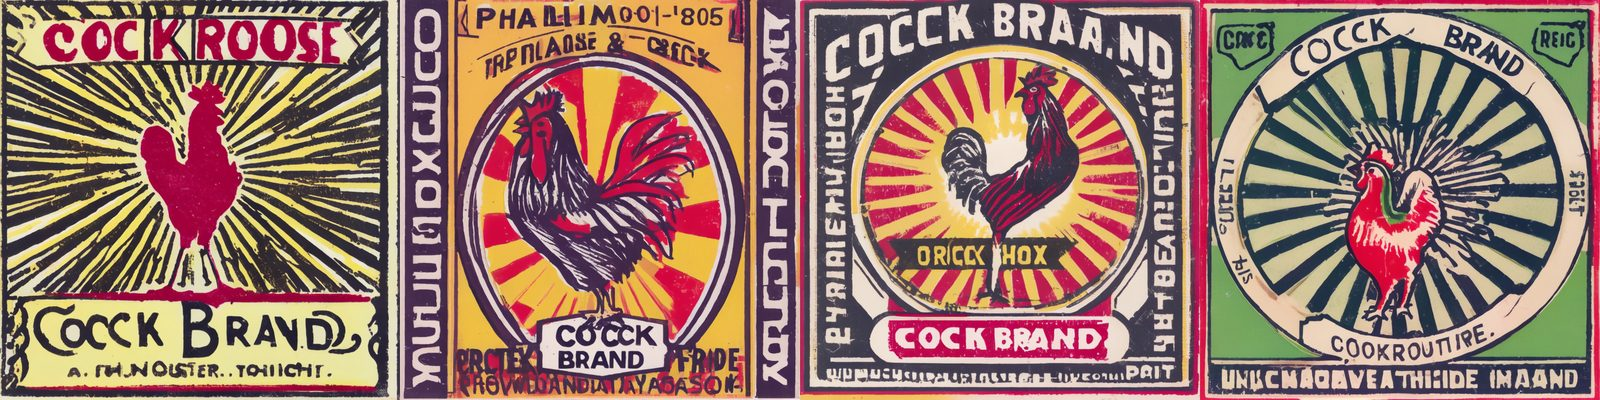

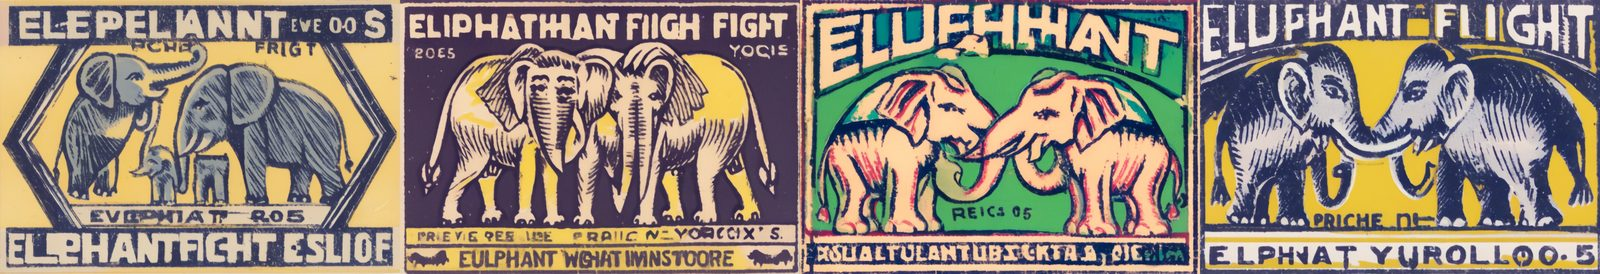

Buffered data was truncated after reaching the output size limit.

In [38]:
SIZES = [("a woman in a green sari lighting a brass oil lamp, blue background, headline 'DEEPA'", 832, 1216),
         ("a big pink lotus flower with green leaves, yellow background, headline 'KAMAL'", 896, 1152),
         ("a tall temple tower under a crescent moon, blue sky, headline 'GOPURAM'", 768, 1344),
         ("a red rooster crowing inside a yellow sunburst, headline 'COCK BRAND'", 1024, 1024),
         ("two blue elephants facing each other, yellow background, headline 'ELEPHANT FIGHT'", 1216, 832),
         ("a white swan swimming in front of a red sunburst, yellow background, headline 'SWAN BRAND'", 1152, 896),
         ("a sailing ship on blue waves at sunset, headline 'SHIP'", 1344, 768)]
for body, w, h in (SIZES[:1] if QUICK else SIZES):
    display(gen(P(body), w=W0 if QUICK else w, h=H0 if QUICK else h))

### 13.4 One image at a time

Run with `seed=None` until you like one, copy the printed seed into `seed=`, then refine that
exact image with `scale` or `cfg`.

seed 478163327  scale 1.0  832x1216  steps 30  cfg 6.0  -> phlmx_a_matchbox_a_peacock_with_a_fanned_tail_in_front_of_a__s1.0_seed478163327_832x1216.png


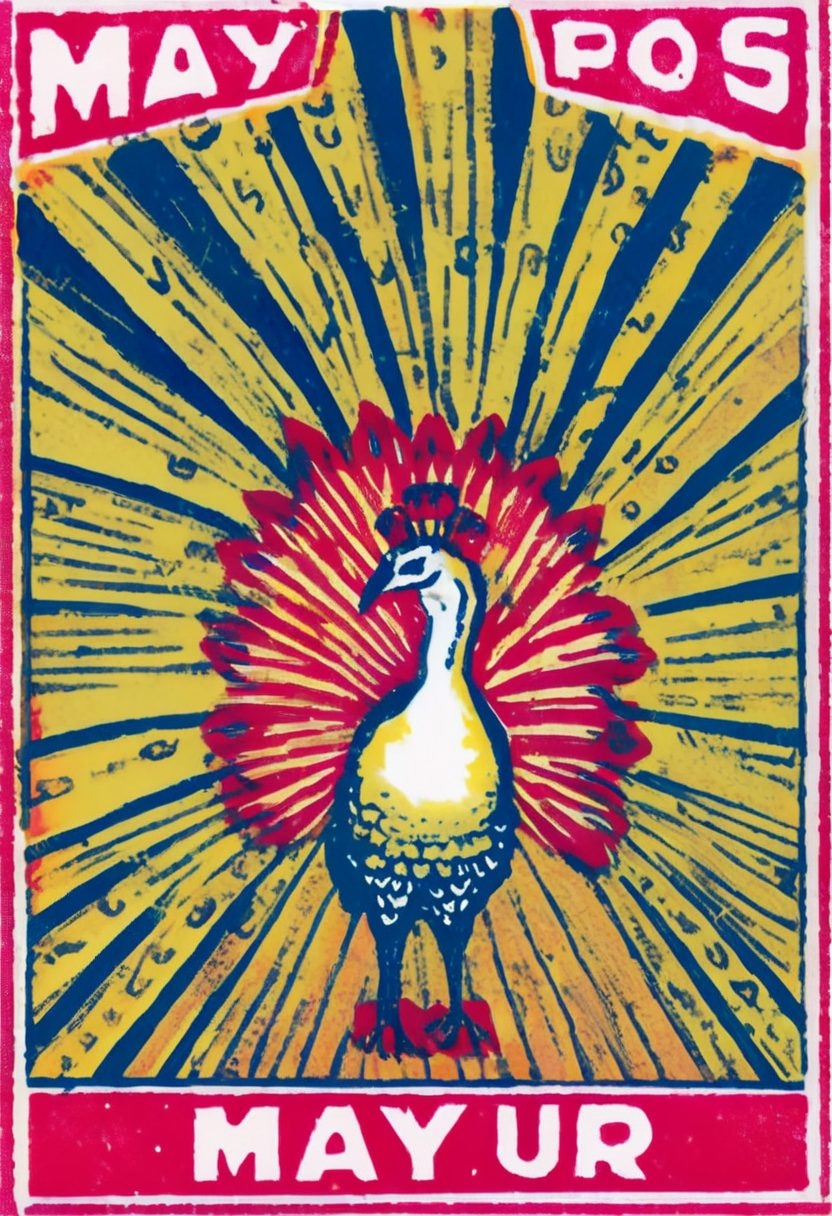

seed 42  scale 0.9  1216x832  steps 30  cfg 6.0  -> phlmx_a_matchbox_two_blue_elephants_facing_each_other_yellow_s0.9_seed42_1216x832.png


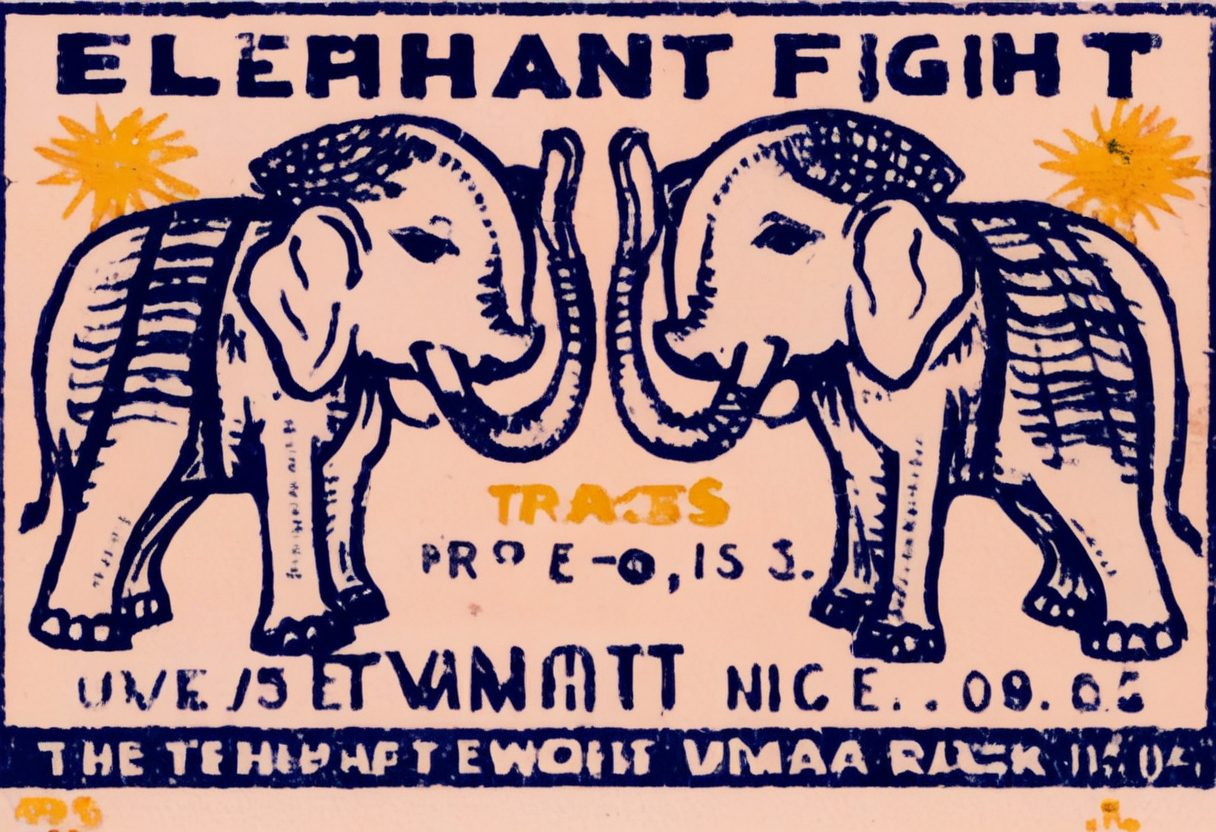

In [39]:
display(gen_one(P("a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR'")))
display(gen_one(P("two blue elephants facing each other, yellow background, headline 'ELEPHANT FIGHT'"),
                scale=0.9, seed=42, w=H0, h=W0))

seed 107420369  scale 1.0  832x1216  steps 30  cfg 6.0  -> phlmx_a_matchbox_a_man_in_black_suit_and_red_tie_smoking_cig_s1.0_seed107420369_832x1216.png


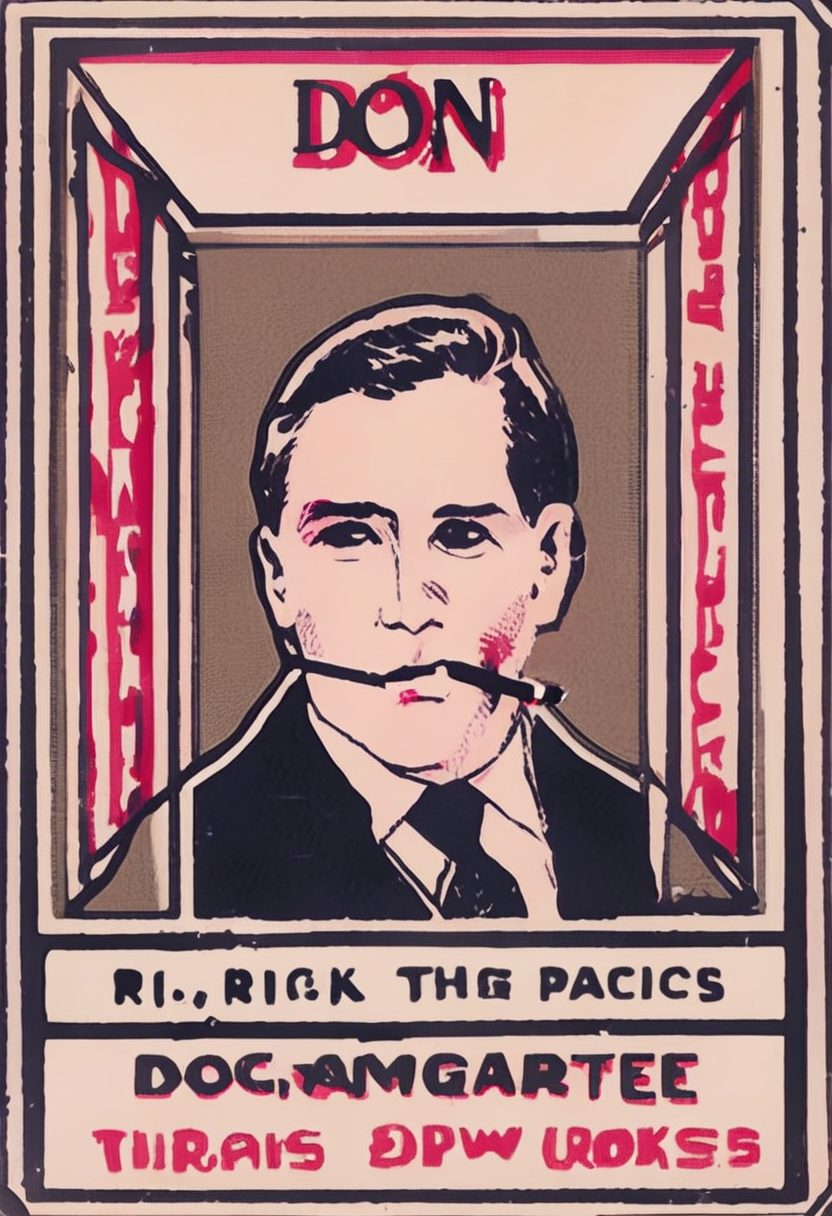

seed 42  scale 0.9  1216x832  steps 30  cfg 6.0  -> phlmx_a_matchbox_two_swans_in_a_pond_with_lotus_blue_backgro_s0.9_seed42_1216x832.png


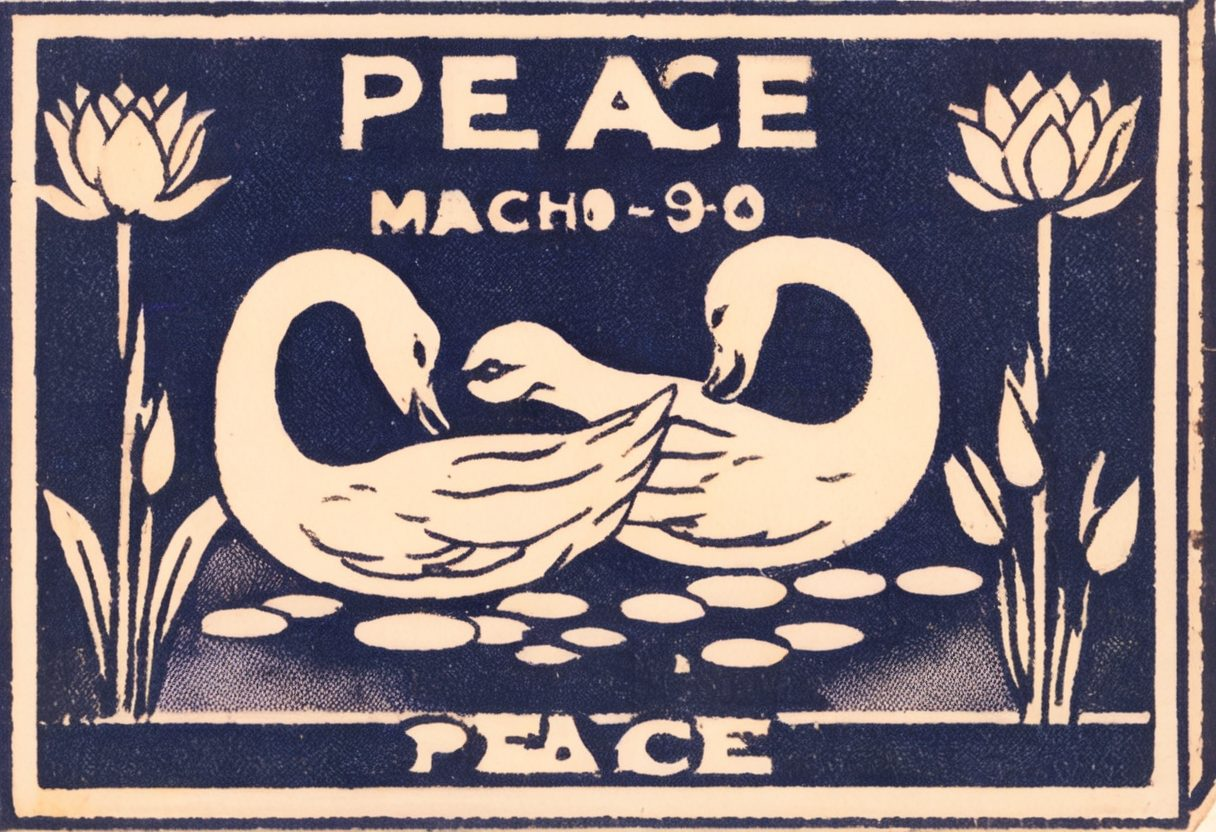

In [40]:
display(gen_one(P("a man in black suit and red tie smoking ciggaretee, white background, headline 'DON'")))
display(gen_one(P("two swans in a pond with lotus, blue background, headline 'PEACE'"),
                scale=0.9, seed=42, w=H0, h=W0))

seed 1181241943  scale 1.0  832x1216  steps 30  cfg 6.0  -> phlmx_a_matchbox_a_man_walking_his_dog_in_park_with_green_tr_s1.0_seed1181241943_832x1216.png


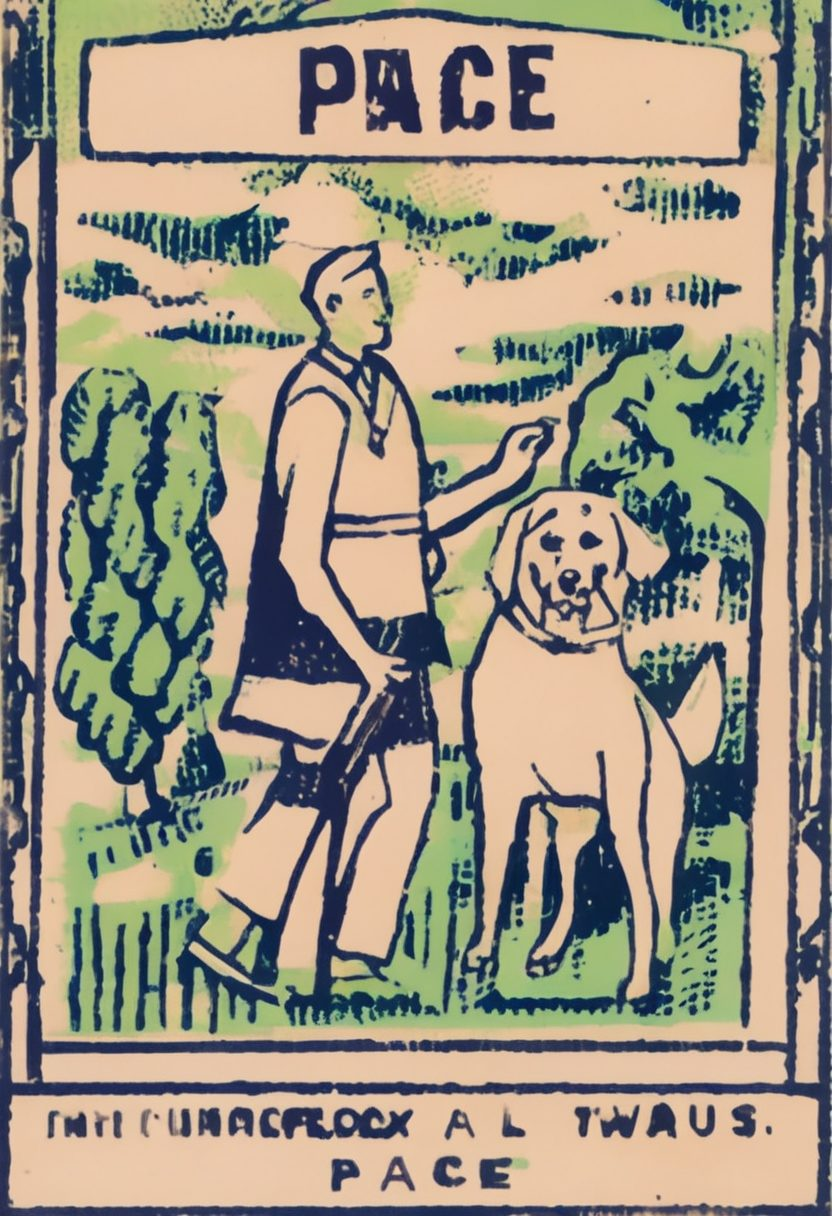

In [41]:
display(gen_one(P("a man walking his dog in park with green trees all around, blue background, headline 'PEACE'")))


---

## Exercises

1. **Break the licence gate on purpose** (museum data: `FT_DATA_NAME = "museum"`). Point
   `STYLE_DS` at a dataset whose card says `cc-by-nc-4.0` and confirm §2.1 stops you. Then find one
   whose card has *no* licence field and decide, in writing, what you would need before training on it.

2. **Leave the duplicates in.** Skip §2.3 (use `pool = uniq`) and plant three copies of one image
   in `TRAIN`. Rerun §9 and watch `probe_nn_max` and `copies` rise for that image first.

3. **Human captions vs the auto-captioner.** In this run the hand-written `.txt` captions
   (`human`) lost the §8 ablation to Florence-2's `content` captions on trigger gain. Train the
   main run with `CHOSEN = "human"` and compare the generated lettering in §13.

4. **Same steps, different checkpoints.** Train `repeats=10, epochs=2` against `repeats=2,
   epochs=10`. The final adapters should be statistically alike. Only the second lets §9 find an
   earlier, better one.

5. **Square crops.** Replace `make_buckets(res)` with `[(res, res)]`. Compare the style score and
   look at what happened to the lettering at the top and bottom of tall labels (the cache makes
   this a one-line change).

6. **Train at alpha = 2r and export.** Set `LORA_ALPHA = 2 * RANK`, comment out the alpha fix in
   §11, and rerun the round trip. The kohya file now loads at half strength, and the
   weight-equality assertion catches it.

7. **CLIP for duplicates.** Swap `dino_img` for `clip_img` in §2.3 and count how many of your
   images get merged into "duplicate" groups. On the matchbox set it is 53 of 197, all of them
   different labels: why does a style-heavy embedding fail at instance matching?

---

**Next:** take the exported kohya file into ComfyUI or AUTOMATIC1111 (or the diffusers file into
your own code). Then do the one evaluation this notebook cannot: fifty prompts of your own, read
by hand.
